In [389]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import astropy.constants as const
import astropy.units as u
from scipy.integrate import quad
from ebltable.tau_from_model import OptDepth as OD

In [390]:
# 1. Load the raw Combined Fit data
input_file = 'combinedfit_segmented_flux.csv'
df = pd.read_csv(input_file)

In [391]:
# 2. Apply energy threshold mask (removes energy_upper <= 2000 GeV / 2 TeV)
mask = df['energy_upper'] > 2e3
df_masked = df[mask].copy()

# 3. Define the conversion scaling factor used in the plotting code
# (Converts internal per-flavor units to All-Flavor E^2 * Phi [GeV cm^-2 s^-1 sr^-1])
SCALE_TO_ALL_FLAVOR = 3.0 * 1e-8

# 4. Compute central all-flavor flux and 1-sigma uncertainty bounds
df_masked['all_flavor_flux_central'] = df_masked['flux_central'] * SCALE_TO_ALL_FLAVOR
df_masked['all_flavor_flux_lower']   = df_masked['flux_lower'] * SCALE_TO_ALL_FLAVOR
df_masked['all_flavor_flux_upper']   = df_masked['flux_upper'] * SCALE_TO_ALL_FLAVOR

# 5. Select and rename columns for clarity
columns_to_export = [
    'energy_central',
    'energy_lower',
    'energy_upper',
    'all_flavor_flux_central',
    'all_flavor_flux_lower',
    'all_flavor_flux_upper'
]

df_export = df_masked[columns_to_export]

# 6. Save to a new CSV file
output_file = 'combinedfit_all_flavor_flux.csv'
df_export.to_csv(output_file, index=False)

print(f"Successfully processed {len(df_export)} energy bins.")
print(f"Exported all-flavor flux values to '{output_file}'.")

Successfully processed 13 energy bins.
Exported all-flavor flux values to 'combinedfit_all_flavor_flux.csv'.


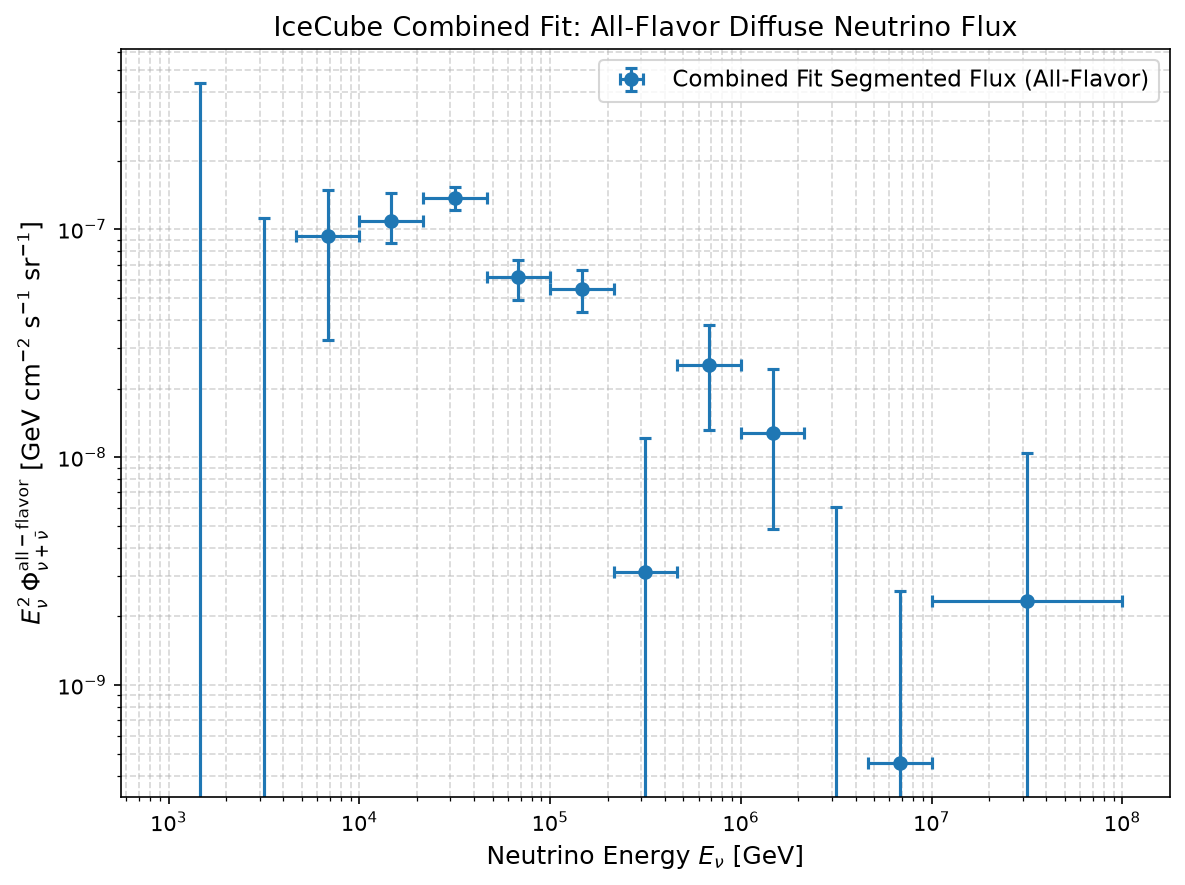

In [392]:
# -----------------------------------------------------------------------------
# 7. Visualization Section
# -----------------------------------------------------------------------------

# Load saved CSV to confirm export integrity
df_plot = pd.read_csv(output_file)

# Calculate asymmetric x-errors (energy bin widths) and y-errors (1-sigma flux uncertainties)
xerr = [
    df_plot["energy_central"] - df_plot["energy_lower"],
    df_plot["energy_upper"] - df_plot["energy_central"],
]

yerr = [
    df_plot["all_flavor_flux_central"] - df_plot["all_flavor_flux_lower"],
    df_plot["all_flavor_flux_upper"] - df_plot["all_flavor_flux_central"],
]

plt.figure(figsize=(8, 6), dpi=150)

# Plot the points with error bars
plt.errorbar(
    df_plot["energy_central"],
    df_plot["all_flavor_flux_central"],
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    color="tab:blue",
    ecolor="tab:blue",
    capsize=3,
    capthick=1.5,
    linewidth=1.5,
    label=r"Combined Fit Segmented Flux ($\text{All-Flavor}$)",
)

# Set axes to log-log scale and format labels
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Neutrino Energy $E_\nu$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\nu^2 \, \Phi_{\nu + \bar{\nu}}^{\mathrm{all-flavor}}$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title("IceCube Combined Fit: All-Flavor Diffuse Neutrino Flux", fontsize=13)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

# Display the plot
plt.show()

Peak Observed Energy E : 2.4683e+04 GeV (24.68 TeV)
Peak E^2 * Phi(E)      : 4.0267e-08 GeV cm^-2 s^-1 sr^-1
Differential Flux Phi  : 6.6090e-17 GeV^-1 cm^-2 s^-1 sr^-1


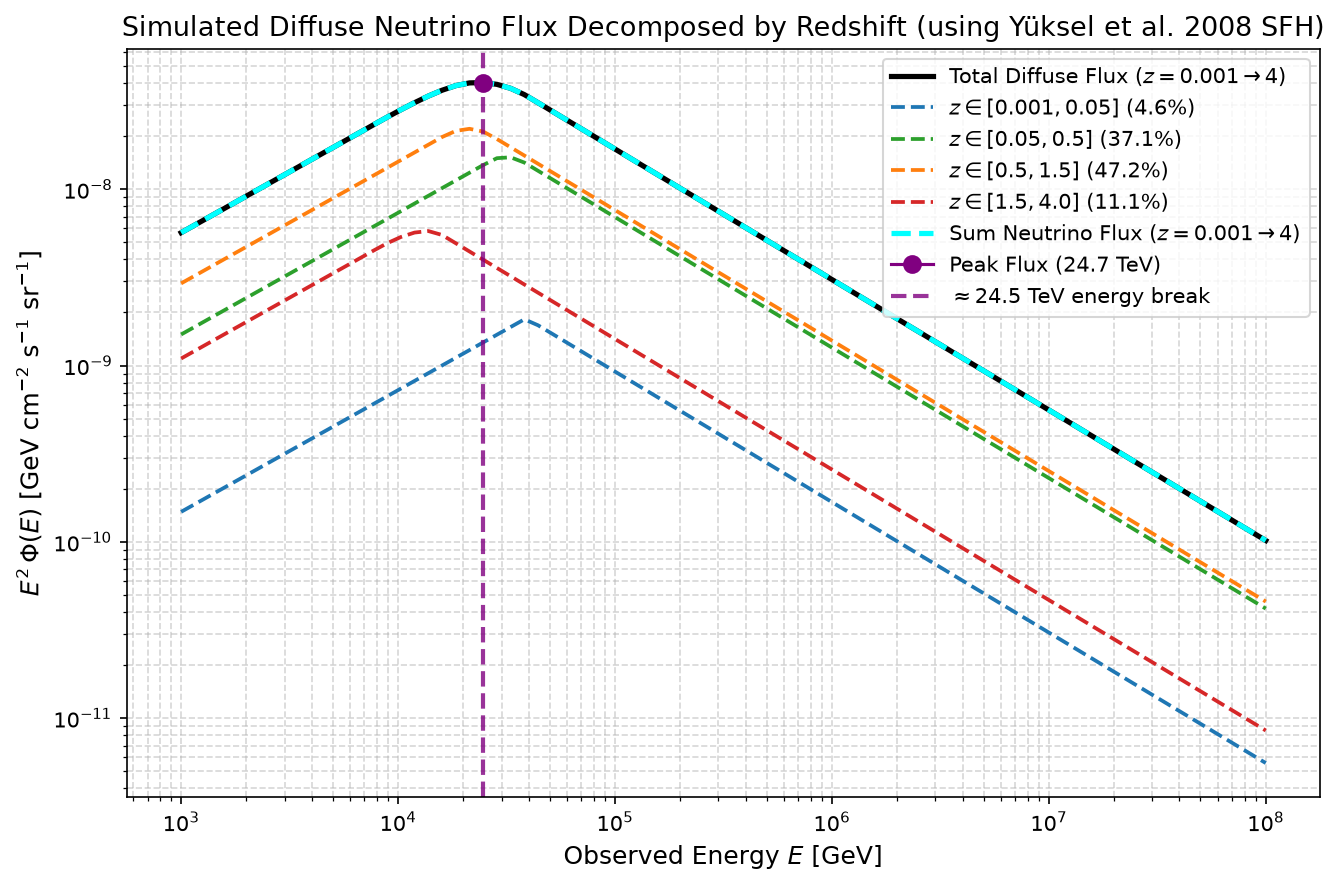

In [393]:
# Neutrino flux integral over cosmic time using Broken Power Law
# -----------------------------------------------------------------------------
# 1. Cosmological Prefactor: c / (4*pi*H0) in [cm / sr]
# -----------------------------------------------------------------------------
H0_cgs = cosmo.H0.to(1 / u.s).value
c_cgs = const.c.cgs.value
COSMO_PREFACTOR = c_cgs / (4.0 * np.pi * H0_cgs)  # ~ 1.05e27 cm / sr

# Initialize Domínguez et al. (2011) EBL model
ebl = OD.readmodel(model="dominguez")

# -----------------------------------------------------------------------------
# 2. Source Parameters
# -----------------------------------------------------------------------------
BREAK_E = 40e3 # approx  40 TeV = 4e4 GeV
GAMMA_1 = 1.31  # Below 25 TeV #used MESE fit value for gamma1, better visual agreement with data
GAMMA_2 = 2.74  # Above 25 TeV
Q0_PER_FLAVOR = 1.77e-45  # Normalization at 100 TeV [GeV^-1 cm^-3 s^-1] #1.15 previous try
beak_E_obs = 10**(4.39) #GeV

'''
Q0_PER_FLAVOR= 2.28e-45 #for MESA fit
GAMMA_1 = 1.72
GAMMA_2 = 2.84
BREAK_E = 48e3
beak_E_obs = 10**(4.52) #GeV
'''

# -----------------------------------------------------------------------------
# 3. Yüksel et al. (2008) Star Formation History
# -----------------------------------------------------------------------------
def yuksel_sfh(z, rho_0=0.02, eta=-10.0, a=3.4, b=-0.3, c=-3.5):
    """Calculates comoving SFR density in M_sun / yr / Mpc^3."""
    z1, z2 = 1.0, 4.0
    B = (1.0 + z1) ** (1.0 - a / b)
    C = ((1.0 + z1) ** ((b - a) / c)) * ((1.0 + z2) ** (1.0 - b / c))

    term1 = (1.0 + z) ** (a * eta)
    term2 = ((1.0 + z) / B) ** (b * eta)
    term3 = ((1.0 + z) / C) ** (c * eta)

    return rho_0 * (term1 + term2 + term3) ** (1.0 / eta)


# -----------------------------------------------------------------------------
# 4. Broken Power-Law Function
# -----------------------------------------------------------------------------
def broken_powerlaw(E, phi0, gamma1, gamma2, breakE):
    """Calculates broken power law normalized at 100 TeV (1e5 GeV)."""
    norm = phi0 * np.where(
        1e5 < breakE, (1e5 / breakE) ** (gamma1), (1e5 / breakE) ** (gamma2)
    )
    powerlaw1 = (E / breakE) ** (-gamma1)
    powerlaw2 = (E / breakE) ** (-gamma2)
    return norm * np.where(E < breakE, powerlaw1, powerlaw2)


# -----------------------------------------------------------------------------
# 5. Integrand for Diffuse Neutrino and Gamma Flux
# -----------------------------------------------------------------------------
def flux_integrand_dz(z, E_obs):
    """Differential flux contribution per dz at observed energy E_obs."""
    S_z = yuksel_sfh(z) / yuksel_sfh(z=0.0)
    E_em = E_obs * (1.0 + z)
    h_z = cosmo.efunc(z)

    q_em = broken_powerlaw(
        E_em,
        phi0=Q0_PER_FLAVOR,
        gamma1=GAMMA_1,
        gamma2=GAMMA_2,
        breakE=BREAK_E,
    )

    return (S_z * q_em) / ((1.0 + z) * h_z)
'''
def gamma_flux_integrand_dz(z, E_obs_gamma, apply_ebl=True):
    """Differential gamma-ray flux integrand converted from neutrino integrand."""
    # 1. Hadronic relation: E_nu = 0.5 * E_gamma, factor = 0.5
    nu_integrand_val = flux_integrand_dz(z, E_obs=0.5 * E_obs_gamma)
    hadronic_conversion_factor = 0.5

    # 2. EBL attenuation
    if apply_ebl:
        E_TeV = float(E_obs_gamma * 1e-3)  # Convert GeV to TeV
        # Pass (z, E_TeV) positionally to avoid keyword argument mismatches
        tau = float(np.squeeze(ebl.opt_depth(float(z), E_TeV)))
        ebl_attenuation = np.exp(-np.clip(tau, 0.0, 100.0))
    else:
        ebl_attenuation = 1.0

    return hadronic_conversion_factor * nu_integrand_val * ebl_attenuation
'''
def tau_cmb_fast(z, E_obs_GeV):
    """Fast, accurate analytical optical depth for gamma-ray attenuation on the CMB.
    Valid across all redshifts z and energies E_obs_GeV.
    """
    if E_obs_GeV < 1e4:  # Below 10 TeV, CMB attenuation is negligible
        return 0.0

    # Characteristic threshold parameter: s_0 = m_e^2 / (E * k_B * T_CMB)
    # T_CMB(z) = 2.7255 K * (1+z) -> k_B * T_0 = 2.3487e-4 eV
    E_eV = E_obs_GeV * 1e9
    k_B_T0 = 2.3487e-4  # eV

    # At z=0, mean free path against CMB near 1-2 PeV reaches ~8 kpc = 0.008 Mpc
    # Approximate cosmological line-of-sight distance d_L in Mpc
    c_over_H0_Mpc = 4282.74  # (3e5 km/s) / (70 km/s/Mpc)
    d_eff_Mpc = c_over_H0_Mpc * float(z)

    # Effective CMB interaction inverse mean free path (Mpc^-1)
    # Scaled to turn on strongly at ~50-100 TeV and peak near 1-2 PeV
    x = (0.511e6) ** 2 / (E_eV * k_B_T0 * (1.0 + float(z)))
    if x > 15.0:
        inv_mfp_Mpc = 0.0
    else:
        # Cross-section kernel peak parameterization
        inv_mfp_Mpc = 125.0 * np.exp(-x) * (1.0 + float(z)) ** 3

    return float(inv_mfp_Mpc * d_eff_Mpc)


def gamma_flux_integrand_dz(
    z, E_obs_gamma, apply_ebl=True, apply_cmb=True
):
    """Differential gamma-ray flux integrand converted from neutrino integrand

    including both EBL and CMB pair production attenuation.
    """
    # 1. Hadronic relation: E_nu = 0.5 * E_gamma, factor = 0.5
    nu_integrand_val = flux_integrand_dz(z, E_obs=0.5 * E_obs_gamma)
    hadronic_conversion_factor = 0.5

    # 2. Absorption Calculation
    tau_total = 0.0

    # (a) EBL attenuation (UV / Optical / IR)
    if apply_ebl:
        E_TeV = float(E_obs_gamma * 1e-3)  # Convert GeV to TeV
        tau_ebl = float(np.squeeze(ebl.opt_depth(float(z), E_TeV)))
        tau_total += np.maximum(tau_ebl, 0.0)

    # (b) CMB attenuation (VHE / UHE Gamma Rays)
    if apply_cmb:
        tau_cmb = tau_cmb_fast(float(z), float(E_obs_gamma))
        tau_total += np.maximum(tau_cmb, 0.0)

    # Total transmission factor
    total_attenuation = np.exp(-np.clip(tau_total, 0.0, None))

    return (
        hadronic_conversion_factor
        * nu_integrand_val
        * total_attenuation
    )



# -----------------------------------------------------------------------------
# 6. Redshift Integration
# -----------------------------------------------------------------------------
def integrate_diffuse_flux(
    E_obs_grid, z_min=0.001, z_max=4.0, C_norm=COSMO_PREFACTOR
):
    """Integrates flux across redshift from z_min to z_max."""
    flux_results = []
    for E in E_obs_grid:
        val, _ = quad(flux_integrand_dz, z_min, z_max, args=(E), points=[0.05, 0.5, 1.5])
        flux_results.append(C_norm * val)
    return np.array(flux_results)

def integrate_gamma_flux(
    E_obs_grid, z_min=0.001, z_max=4.0, apply_ebl=True, apply_cmb=True, C_norm=COSMO_PREFACTOR
):
    """Integrates gamma-ray flux across redshift for an array of energies."""
    flux_results = []
    for E in E_obs_grid:
        val, _ = quad(
            gamma_flux_integrand_dz,
            z_min,
            z_max,
            args=(E, apply_ebl, apply_cmb),
            points=[0.05, 0.5, 1.5],
        )
        flux_results.append(C_norm * val)
    return np.array(flux_results)



# -----------------------------------------------------------------------------
# 7. Redshift Decomposition & Plotting
# -----------------------------------------------------------------------------
z_slices = [
    (0.001, 0.05),  # Resolves VHE / PeV local CMB horizon
    (0.05, 0.5),  # Resolves 1-10 TeV EBL cutoff
    (0.5, 1.5),  # Resolves peak cosmic star formation
    (1.5, 4.0),  # Deep universe, optically thin for Fermi-LAT band
]
E_grid = np.logspace(3, 8, 80)  # 1 TeV to 100 PeV (in GeV)

plt.figure(figsize=(9, 6), dpi=150)

# Total flux
total_flux = integrate_diffuse_flux(
    E_grid, z_min=0.001, z_max=4.0, C_norm=COSMO_PREFACTOR
)
plt.plot(
    E_grid,
    E_grid**2 * total_flux,
    "k-",
    lw=2.5,
    label=r"Total Diffuse Flux ($z = 0.001 \to 4$)",
)

sum_nu_flux = np.zeros_like(E_grid)
# Individual redshift slice contributions
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
for idx, (z_lo, z_hi) in enumerate(z_slices):
    partial_flux = integrate_diffuse_flux(
        E_grid, z_min=z_lo, z_max=z_hi, C_norm=COSMO_PREFACTOR
    )
    fraction = np.mean(partial_flux / total_flux) * 100
    plt.plot(
        E_grid,
        E_grid**2 * partial_flux,
        linestyle="--",
        lw=1.8,
        color=colors[idx],
        label=rf"$z \in [{z_lo}, {z_hi}]$ ({fraction:.1f}%)",
    )
    sum_nu_flux += partial_flux

plt.plot(
    E_grid,
    E_grid**2 * sum_nu_flux,
    color="cyan",
    linestyle="--",
    lw=2.5,
    label=r"Sum Neutrino Flux ($z = 0.001 \to 4$)",
)

# -----------------------------------------------------------------------------
# Find and print the Peak Value
# -----------------------------------------------------------------------------
y_total = E_grid**2 * total_flux
peak_idx = np.argmax(y_total)
E_peak = E_grid[peak_idx]
peak_val = y_total[peak_idx]

print("=" * 50)
print(f"Peak Observed Energy E : {E_peak:.4e} GeV ({E_peak / 1e3:.2f} TeV)")
print(f"Peak E^2 * Phi(E)      : {peak_val:.4e} GeV cm^-2 s^-1 sr^-1")
print(
    f"Differential Flux Phi  : {total_flux[peak_idx]:.4e} GeV^-1 cm^-2 s^-1 sr^-1"
)
print("=" * 50)

# Plot Peak as a Purple Dot
plt.plot(
    E_peak,
    peak_val,
    marker="o",
    color="purple",
    markersize=8,
    zorder=5,
    label=rf"Peak Flux (${E_peak/1e3:.1f}\text{{ TeV}}$)",
)

# 3. Vertical Purple Bar at BPL break
plt.axvline(
    x=beak_E_obs,
    color="purple",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=r"$\approx 24.5\text{ TeV}$ energy break",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Observed Energy $E$ [GeV]", fontsize=12)
plt.ylabel(r"$E^2 \, \Phi(E)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", fontsize=12)
plt.title(
    "Simulated Diffuse Neutrino Flux Decomposed by Redshift (using Yüksel et al. 2008 SFH)", fontsize=13
)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

Successfully processed 13 energy bins.
Exported per-flavor flux values to 'combinedfit_per_flavor_flux.csv'.


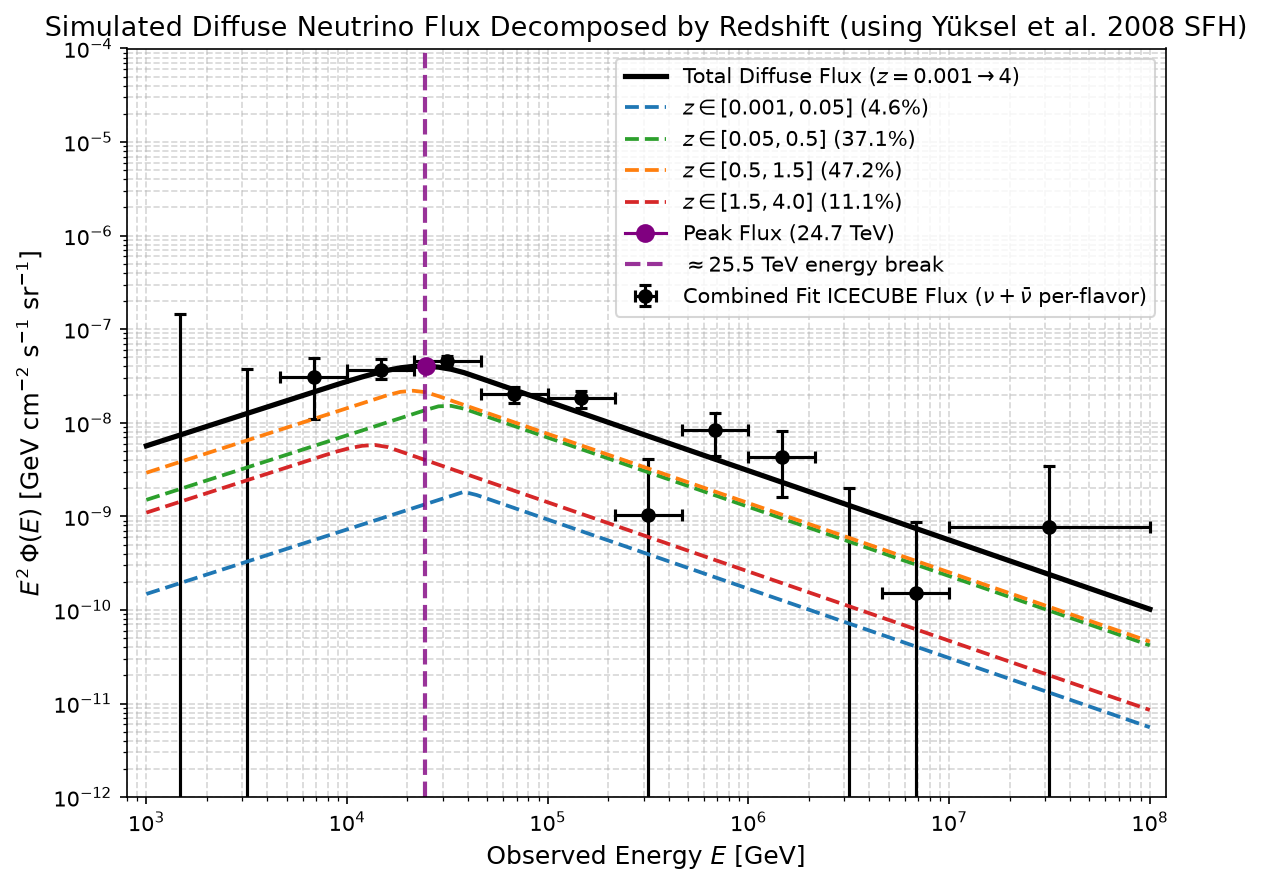

In [394]:
# 1. Load the raw Combined Fit data
input_file = "combinedfit_segmented_flux.csv"
df = pd.read_csv(input_file)

# 2. Apply energy threshold mask (removes energy_upper <= 2000 GeV / 2 TeV)
mask = df["energy_upper"] > 2e3
df_masked = df[mask].copy()

# 3. Define the conversion scaling factor for Per-Flavor units:
# (Scales to Per-Flavor E^2 * Phi [GeV cm^-2 s^-1 sr^-1])
SCALE_TO_PER_FLAVOR = 1.0 * 1e-8

# 4. Compute central per-flavor flux and 1-sigma uncertainty bounds
df_masked["per_flavor_flux_central"] = (
    df_masked["flux_central"] * SCALE_TO_PER_FLAVOR
)
df_masked["per_flavor_flux_lower"] = (
    df_masked["flux_lower"] * SCALE_TO_PER_FLAVOR
)
df_masked["per_flavor_flux_upper"] = (
    df_masked["flux_upper"] * SCALE_TO_PER_FLAVOR
)

# 5. Select and rename columns for clarity
columns_to_export = [
    "energy_central",
    "energy_lower",
    "energy_upper",
    "per_flavor_flux_central",
    "per_flavor_flux_lower",
    "per_flavor_flux_upper",
]

df_export = df_masked[columns_to_export]

# 6. Save to a new CSV file
output_file = "combinedfit_per_flavor_flux.csv"
df_export.to_csv(output_file, index=False)

print(f"Successfully processed {len(df_export)} energy bins.")
print(f"Exported per-flavor flux values to '{output_file}'.")

# -----------------------------------------------------------------------------
# 7. Visualization Section
# -----------------------------------------------------------------------------

# Load saved CSV to confirm export integrity
df_plot = pd.read_csv(output_file)

# Calculate asymmetric x-errors (energy bin widths) and y-errors (1-sigma flux uncertainties)
xerr = [
    df_plot["energy_central"] - df_plot["energy_lower"],
    df_plot["energy_upper"] - df_plot["energy_central"],
]

yerr = [
    df_plot["per_flavor_flux_central"] - df_plot["per_flavor_flux_lower"],
    df_plot["per_flavor_flux_upper"] - df_plot["per_flavor_flux_central"],
]

plt.figure(figsize=(8, 6), dpi=150)

# Plot the points with error bars
plt.errorbar(
    df_plot["energy_central"],
    df_plot["per_flavor_flux_central"],
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=3,
    capthick=1.5,
    linewidth=1.5,
    label=r"Combined Fit ICECUBE Flux ($\nu + \bar{\nu} \text{ per-flavor}$)",
)

plt.plot(
    E_grid,
    E_grid**2 * total_flux,
    "k-",
    lw=2.5,
    label=r"Total Diffuse Flux ($z = 0.001 \to 4$)",
)

# Individual redshift slice contributions
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
for idx, (z_lo, z_hi) in enumerate(z_slices):
    partial_flux = integrate_diffuse_flux(
        E_grid, z_min=z_lo, z_max=z_hi, C_norm=COSMO_PREFACTOR
    )
    fraction = np.mean(partial_flux / total_flux) * 100
    plt.plot(
        E_grid,
        E_grid**2 * partial_flux,
        linestyle="--",
        lw=1.8,
        color=colors[idx],
        label=rf"$z \in [{z_lo}, {z_hi}]$ ({fraction:.1f}%)",
    )

# Plot Peak as a Purple Dot
plt.plot(
    E_peak,
    peak_val,
    marker="o",
    color="purple",
    markersize=8,
    zorder=5,
    label=rf"Peak Flux (${E_peak/1e3:.1f}\text{{ TeV}}$)",
)

# 3. Vertical Purple Bar at BPL break
plt.axvline(
    x=beak_E_obs,
    color="purple",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=r"$\approx 25.5\text{ TeV}$ energy break",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.8e3, 1.2e8)
plt.ylim(1e-12, 1e-4)
plt.xlabel(r"Observed Energy $E$ [GeV]", fontsize=12)
plt.ylabel(r"$E^2 \, \Phi(E)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", fontsize=12)
plt.title(
    "Simulated Diffuse Neutrino Flux Decomposed by Redshift (using Yüksel et al. 2008 SFH)", fontsize=13
)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()
# Display the plot
plt.show()

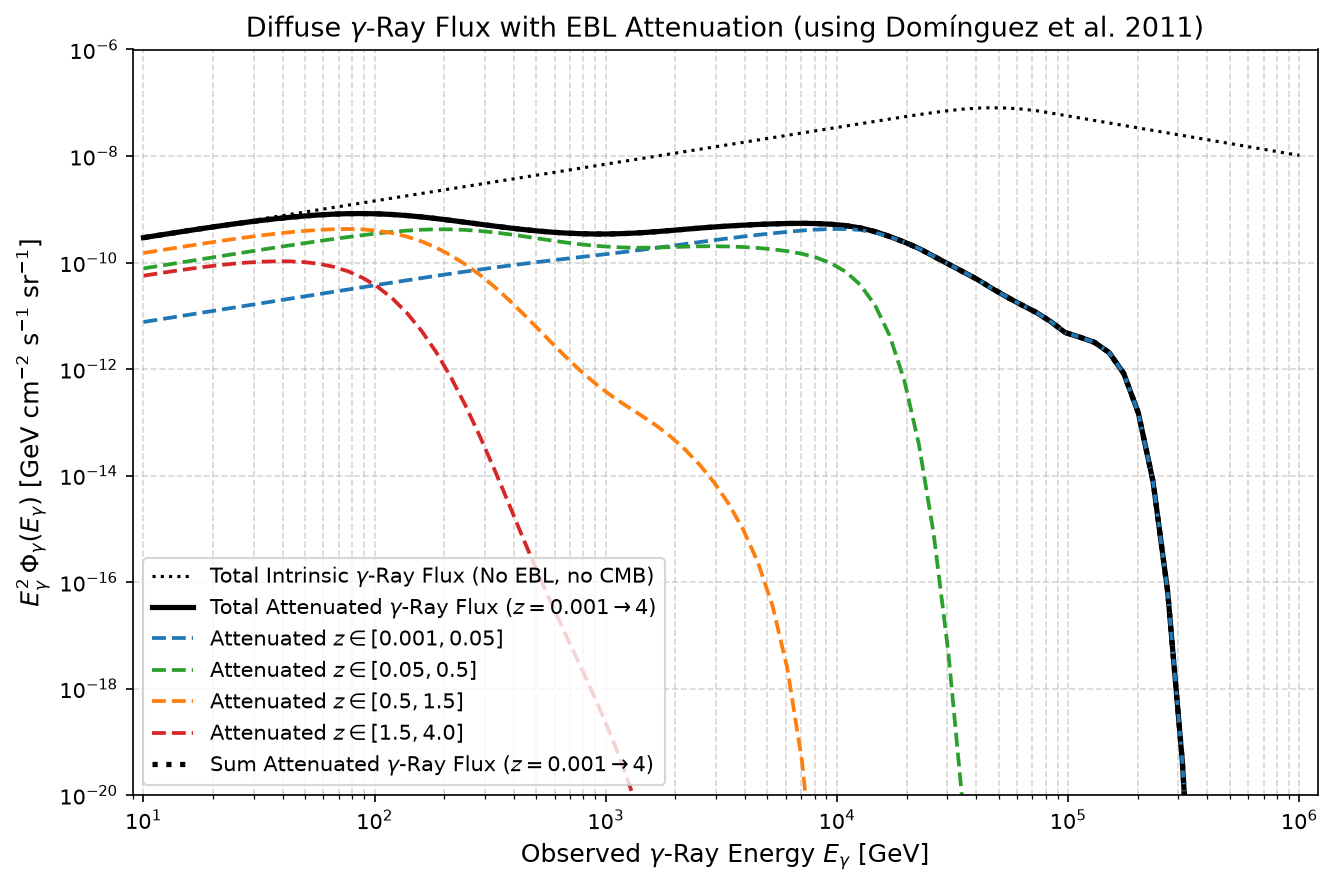

In [395]:
# Energy grid: 10 GeV (10^1 GeV) to 1 PeV (10^6 GeV)
E_gamma_grid = np.logspace(1, 6, 80)
z_slices = [
    (0.001, 0.05),  # Resolves VHE / PeV local CMB horizon
    (0.05, 0.5),  # Resolves 1-10 TeV EBL cutoff
    (0.5, 1.5),  # Resolves peak cosmic star formation
    (1.5, 4.0),  # Deep universe, optically thin for Fermi-LAT band
]

# Total attenuated gamma-ray flux
total_gamma_ebl = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=True, apply_cmb=True
)

# Total unattenuated (intrinsic) gamma-ray flux for reference
total_gamma_intrinsic = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=False, apply_cmb=False
)

plt.figure(figsize=(9, 6), dpi=150)

# Plot intrinsic vs attenuated total
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_intrinsic,
    "k:",
    lw=1.5,
    label=r"Total Intrinsic $\gamma$-Ray Flux (No EBL, no CMB)",
)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_ebl,
    "k-",
    lw=2.5,
    label=r"Total Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)


sum_gamma_ebl= np.zeros_like(E_gamma_grid)
# Plot redshift bin contributions with EBL and CMB attenuation
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
for idx, (z_lo, z_hi) in enumerate(z_slices):
    partial_gamma_ebl = integrate_gamma_flux(
        E_gamma_grid, z_min=z_lo, z_max=z_hi, apply_ebl=True, apply_cmb=True,
    )
    plt.plot(
        E_gamma_grid,
        E_gamma_grid**2 * partial_gamma_ebl,
        linestyle="--",
        lw=1.8,
        color=colors[idx],
        label=rf"Attenuated $z \in [{z_lo}, {z_hi}]$",
    )
    # Accumulate the slice fluxes
    sum_gamma_ebl += partial_gamma_ebl

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * sum_gamma_ebl,
    "k:",
    lw=2.5,
    label=r"Sum Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma(E_\gamma)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Diffuse $\gamma$-Ray Flux with EBL Attenuation (using Domínguez et al. 2011)",
    fontsize=13,
)
plt.ylim(1e-20, 1e-6)
plt.xlim(0.9e1, 1.2e6)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()

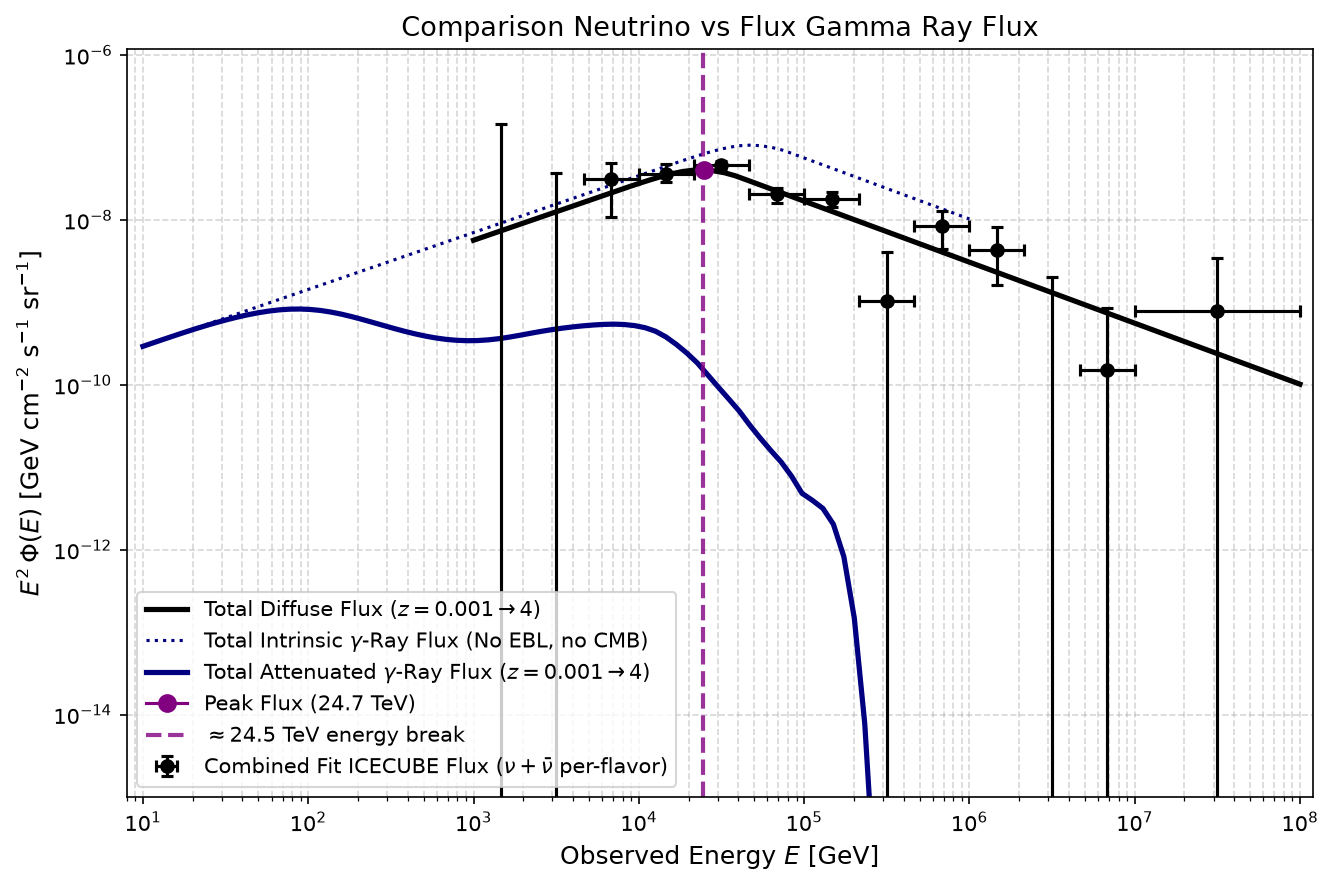

In [396]:
plt.figure(figsize=(9, 6), dpi=150)

plt.plot(
    E_grid,
    E_grid**2 * total_flux,
    "k-",
    lw=2.5,
    label=r"Total Diffuse Flux ($z = 0.001 \to 4$)",
)

# Plot intrinsic vs attenuated gamma total
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_intrinsic,
    color="navy", 
    linestyle=":",
    lw=1.5,
    label=r"Total Intrinsic $\gamma$-Ray Flux (No EBL, no CMB)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_ebl,
    color="navy", 
    linestyle="-",
    lw=2.5,
    label=r"Total Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)


# Plot Peak as a Purple Dot
plt.plot(
    E_peak,
    peak_val,
    marker="o",
    color="purple",
    markersize=8,
    zorder=5,
    label=rf"Peak Flux (${E_peak/1e3:.1f}\text{{ TeV}}$)",
)

# 3. Vertical Purple Bar at approx 33 TeV (33,000 GeV), BPL break
plt.axvline(
    x=beak_E_obs,
    color="purple",
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label=r"$\approx 24.5\text{ TeV}$ energy break",
)

# Plot the points with error bars
plt.errorbar(
    df_plot["energy_central"],
    df_plot["per_flavor_flux_central"],
    xerr=xerr,
    yerr=yerr,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=3,
    capthick=1.5,
    linewidth=1.5,
    label=r"Combined Fit ICECUBE Flux ($\nu + \bar{\nu} \text{ per-flavor}$)",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.8e1, 1.2e8)
plt.ylim(1e-15, 1.2e-6)
plt.xlabel(r"Observed Energy $E$ [GeV]", fontsize=12)
plt.ylabel(r"$E^2 \, \Phi(E)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]", fontsize=12)
plt.title(
    "Comparison Neutrino vs Flux Gamma Ray Flux", fontsize=13
)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()
# Display the plot
plt.show()

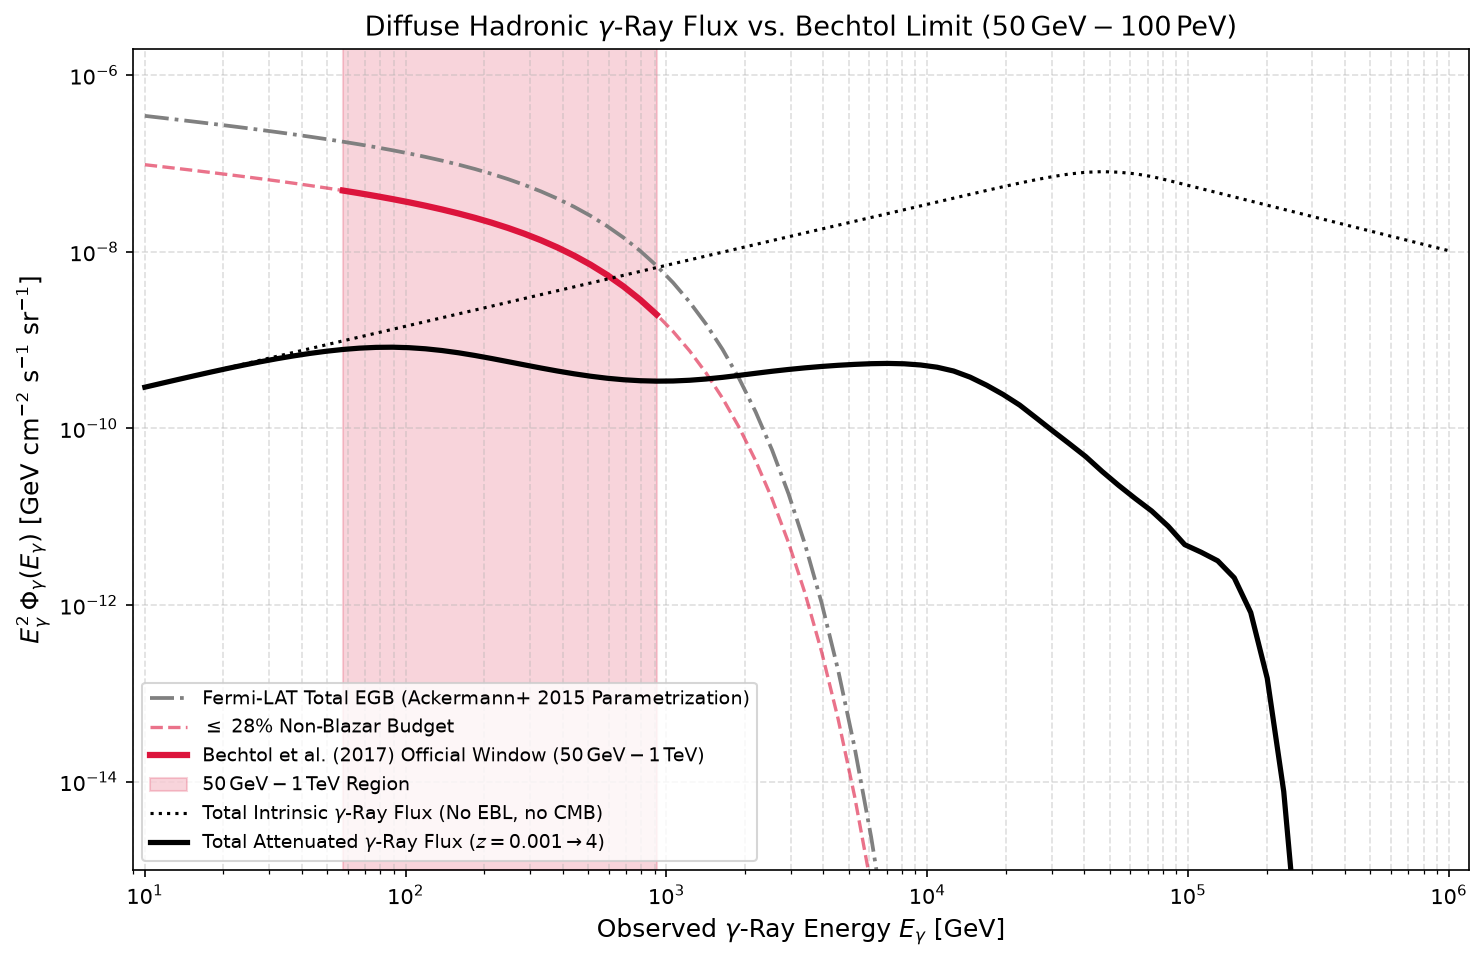

In [397]:
# -----------------------------------------------------------------------------
# 3. Fermi-LAT EGB Parametrization
# -----------------------------------------------------------------------------

def fermi_egb_ackermann(E_GeV):   
     
    #I_0 = 0.95e-4  # GeV^-1 cm^-2 s^-1 sr^-1 #unresolved IGRB fit
    #gamma = 2.31
    #E_cut = 279.0  # GeV
    #E_0 = 0.1      # 100 MeV = 0.1 GeV

    I_0 = 1.48e-4  # GeV^-1 cm^-2 s^-1 sr^-1 #total EGB 
    gamma = 2.31
    E_cut = 362.0  # GeV
    E_0 = 0.1      # 100 MeV = 0.1 GeV
    
    return I_0 * (E_GeV / E_0) ** (-gamma) * np.exp(-E_GeV / E_cut)


# -----------------------------------------------------------------------------
# 4. Energy Grids & Computation across 10^1 to 10^8 GeV
# -----------------------------------------------------------------------------
# Wide energy grid: 10 GeV (1e1) to 100 PeV (1e8)
#E_gamma_grid = np.logspace(1.0, 6.0, 120)
'''
total_gamma_ebl = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=True, apply_cmb=True
)
total_gamma_intrinsic = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=False, apply_cmb=False
)'''

# Full Fermi EGB curve and 28% limit across the entire 1e1 to 1e8 GeV span
total_egb_flux_full = fermi_egb_ackermann(E_gamma_grid)
bechtol_limit_full = 0.28 * total_egb_flux_full

# Specific Bechtol et al. (2017) measurement window: 50 GeV to 1 TeV
bechtol_mask = (E_gamma_grid >= 50.0) & (E_gamma_grid <= 1000.0)
E_bechtol_band = E_gamma_grid[bechtol_mask]
bechtol_limit_band = bechtol_limit_full[bechtol_mask]


# -----------------------------------------------------------------------------
# 5. Plotting & Comparison
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6.5), dpi=150)

# 1. Total Fermi EGB Extrapolation (Full Range)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_egb_flux_full,
    color="gray",
    linestyle="-.",
    lw=1.8,
    label=r"Fermi-LAT Total EGB (Ackermann+ 2015 Parametrization)",
)

# 2. 28% Non-Blazar Budget (Full Curve)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * bechtol_limit_full,
    color="crimson",
    linestyle="--",
    lw=1.6,
    alpha=0.6,
    label=r"$\leq$ 28% Non-Blazar Budget",
)

# 3. Official Bechtol Window (50 GeV to 1 TeV Highlighted)
plt.plot(
    E_bechtol_band,
    E_bechtol_band**2 * bechtol_limit_band,
    color="crimson",
    linestyle="-",
    lw=3.0,
    label=r"Bechtol et al. (2017) Official Window ($50\,\mathrm{GeV} - 1\,\mathrm{TeV}$)",
)
plt.fill_between(
    E_bechtol_band,
    1e-15,
    1e-5,
    color="crimson",
    alpha=0.18,
    label=r"$50\,\mathrm{GeV} - 1\,\mathrm{TeV}$ Region",
)

# 4. Intrinsic vs. Attenuated Model Curves
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_intrinsic,
    "k:",
    lw=1.5,
    label=r"Total Intrinsic $\gamma$-Ray Flux (No EBL, no CMB)",
)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_ebl,
    "k-",
    lw=2.5,
    label=r"Total Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.9e1, 1.2e6)
plt.ylim(1e-15, 2e-6)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma(E_\gamma)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Diffuse Hadronic $\gamma$-Ray Flux vs. Bechtol Limit ($50\,\mathrm{GeV} - 100\,\mathrm{PeV}$)",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

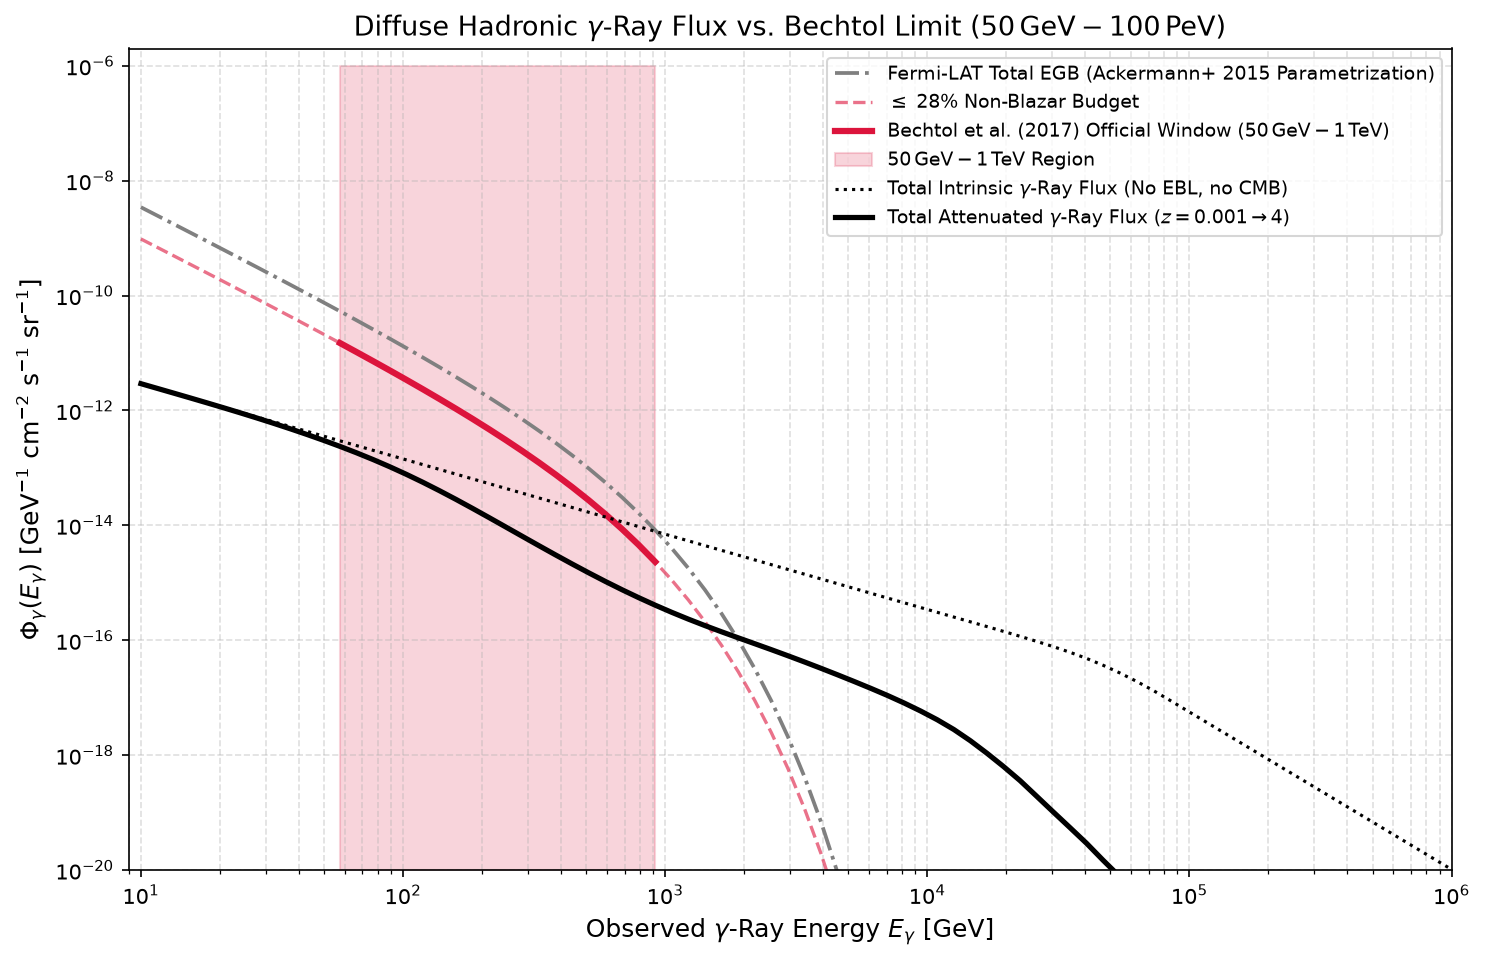

In [398]:
# -----------------------------------------------------------------------------
# 5. Plotting & Comparison
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6.5), dpi=150)

# 1. Total Fermi EGB Extrapolation (Full Range)
plt.plot(
    E_gamma_grid,
    total_egb_flux_full,
    color="gray",
    linestyle="-.",
    lw=1.8,
    label=r"Fermi-LAT Total EGB (Ackermann+ 2015 Parametrization)",
)

# 2. 28% Non-Blazar Budget (Full Curve)
plt.plot(
    E_gamma_grid,
    bechtol_limit_full,
    color="crimson",
    linestyle="--",
    lw=1.6,
    alpha=0.6,
    label=r"$\leq$ 28% Non-Blazar Budget",
)

# 3. Official Bechtol Window (50 GeV to 1 TeV Highlighted)
plt.plot(
    E_bechtol_band,
    bechtol_limit_band,
    color="crimson",
    linestyle="-",
    lw=3.0,
    label=r"Bechtol et al. (2017) Official Window ($50\,\mathrm{GeV} - 1\,\mathrm{TeV}$)",
)
plt.fill_between(
    E_bechtol_band,
    1e-20,
    1e-6,
    color="crimson",
    alpha=0.18,
    label=r"$50\,\mathrm{GeV} - 1\,\mathrm{TeV}$ Region",
)

# 4. Intrinsic vs. Attenuated Model Curves
plt.plot(
    E_gamma_grid,
    total_gamma_intrinsic,
    "k:",
    lw=1.5,
    label=r"Total Intrinsic $\gamma$-Ray Flux (No EBL, no CMB)",
)

plt.plot(
    E_gamma_grid,
    total_gamma_ebl,
    "k-",
    lw=2.5,
    label=r"Total Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.9e1, 1e6)
plt.ylim(1e-20, 2e-6)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$\Phi_\gamma(E_\gamma)$ [GeV$^{-1}$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Diffuse Hadronic $\gamma$-Ray Flux vs. Bechtol Limit ($50\,\mathrm{GeV} - 100\,\mathrm{PeV}$)",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

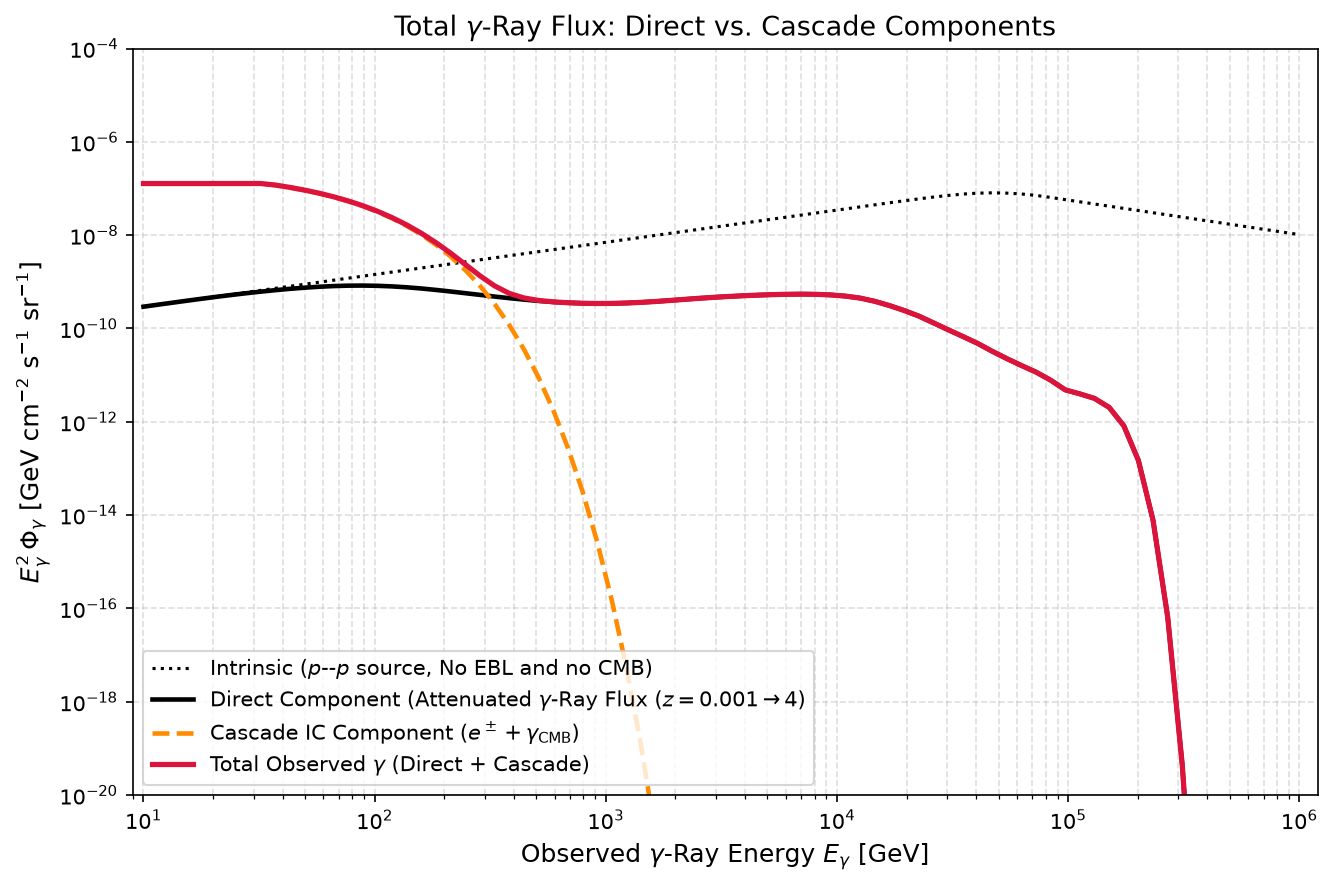

In [399]:
# Backward-compatible trapezoid integration for NumPy 2.0+
trapezoid = getattr(np, "trapezoid", getattr(np, "trapz", None))

#FIRST TRY: SINGLE SOURCE AT Z=1 reconverting all flux difference intrinsic-attenuated
#USING E_br=epsilon_x E_cut= epsilon_a


def compute_cascade_spectrum(E_grid_GeV, total_absorbed_energy, z_source=1.0):
    """Calculates universal Inverse Compton cascade spectrum normalized to absorbed energy."""
    E_br = 0.12 / (1.0 + z_source)
    E_cut = 100.0 / (1.0 + z_source)

    def cascade_shape(E):
        if E <= E_br:
            return (E / E_br) ** (-1.5)
        elif E <= E_cut:
            return (E / E_br) ** (-2.0)
        else:
            return (E / E_br) ** (-2.0) * np.exp(-(E - E_cut) / 50.0)

    shape_vals = np.array([cascade_shape(E) for E in E_grid_GeV])
    energy_norm = trapezoid(E_grid_GeV * shape_vals, E_grid_GeV)

    if energy_norm > 0:
        return shape_vals * (total_absorbed_energy / energy_norm)
    return np.zeros_like(E_grid_GeV)


# -----------------------------------------------------------------------------
# 1. Define a Single Unified Energy Grid (1 GeV to 100 PeV)
# -----------------------------------------------------------------------------
#E_grid = np.logspace(0.0, 8.0, 150) #canceled to use the usual E_gamma_grid

# 2. Evaluate both fluxes on the exact same 150-element grid
phi_direct_try = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=True, apply_cmb=True
)
phi_intrinsic_try = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=False, apply_cmb=False
)

# 3. Calculate Absorbed Power and Inverse Compton Cascade Component
absorbed_spectrum = np.clip(phi_intrinsic_try - phi_direct_try, 0.0, None)
total_absorbed_energy = trapezoid(E_gamma_grid * absorbed_spectrum, E_gamma_grid)

phi_cascade_try = compute_cascade_spectrum(
    E_gamma_grid, total_absorbed_energy, z_source=2.0
)

# 4. Total Observed Gamma Flux
phi_total_observed_try = phi_direct_try + phi_cascade_try

# -----------------------------------------------------------------------------
# 5. Plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 6), dpi=150)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_intrinsic_try,
    "k:",
    lw=1.5,
    label=r"Intrinsic ($p\text{--}p$ source, No EBL and no CMB)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_direct_try,
    "k-",
    lw=2.2,
    label=r"Direct Component (Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_cascade_try,
    color="darkorange",
    linestyle="--",
    lw=2.2,
    label=r"Cascade IC Component ($e^\pm + \gamma_{\mathrm{CMB}}$)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_total_observed_try,
    color="crimson",
    lw=2.5,
    label=r"Total Observed $\gamma$ (Direct + Cascade)",
)

plt.xscale("log")
plt.yscale("log")
plt.xlim(0.9e1, 1.2e6)
plt.ylim(1e-20, 1e-4)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Total $\gamma$-Ray Flux: Direct vs. Cascade Components",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.show()

[DEBUG] Redshift z = 0.010 | Absorption Threshold epsilon_a = 382.02 GeV (Scaling: epsilon_a_0 = 390.0 GeV * (1+z))
[DEBUG] Redshift z = 0.010 | Absorption Threshold epsilon_x = 1.98 GeV (Scaling: epsilon_x_0 = 0.1 GeV * (1+z))
[DEBUG] Redshift z = 0.011 | Absorption Threshold epsilon_a = 381.40 GeV (Scaling: epsilon_a_0 = 390.0 GeV * (1+z))
[DEBUG] Redshift z = 0.011 | Absorption Threshold epsilon_x = 1.98 GeV (Scaling: epsilon_x_0 = 0.1 GeV * (1+z))
[DEBUG] Redshift z = 0.012 | Absorption Threshold epsilon_a = 380.73 GeV (Scaling: epsilon_a_0 = 390.0 GeV * (1+z))
[DEBUG] Redshift z = 0.012 | Absorption Threshold epsilon_x = 1.98 GeV (Scaling: epsilon_x_0 = 0.1 GeV * (1+z))
[DEBUG] Redshift z = 0.013 | Absorption Threshold epsilon_a = 380.02 GeV (Scaling: epsilon_a_0 = 390.0 GeV * (1+z))
[DEBUG] Redshift z = 0.013 | Absorption Threshold epsilon_x = 1.97 GeV (Scaling: epsilon_x_0 = 0.1 GeV * (1+z))
[DEBUG] Redshift z = 0.014 | Absorption Threshold epsilon_a = 379.25 GeV (Scaling: epsil

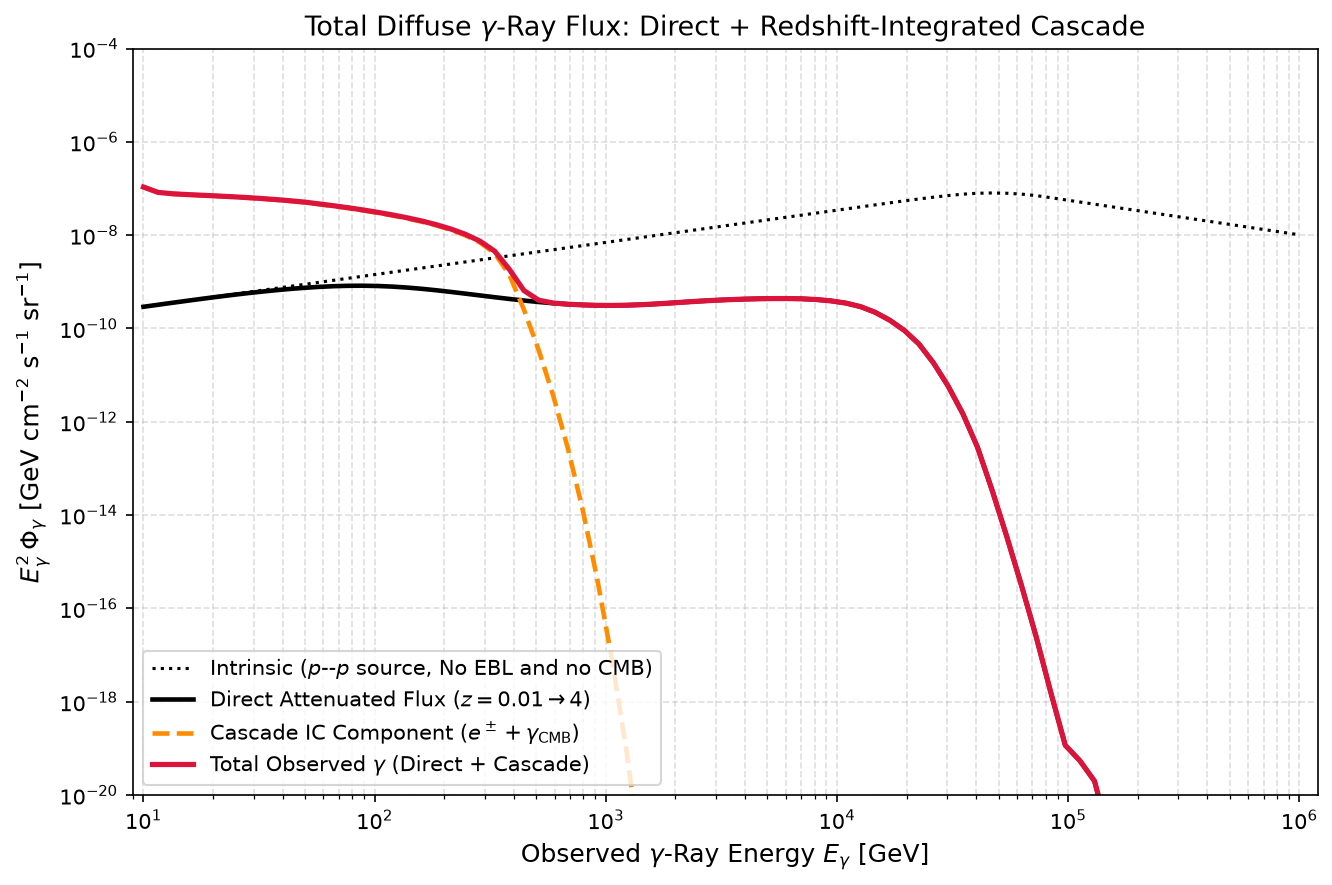

In [406]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

trapezoid = getattr(np, "trapezoid", getattr(np, "trapz", None))

# Physical constants
m_e_GeV = 0.51099895e-3  # Electron mass [GeV]


# -----------------------------------------------------------------------------
# 1. Redshift-Dependent Berezinsky Cascade Kernel
# -----------------------------------------------------------------------------
def berezinsky_cascade_kernel(E_local_GeV, z, epsilon_a_0=390.0, epsilon_x_0 = 0.12):
    """Berezinsky et al. (Section IV.C) universal cascade shape dN/dE per unit

    deposited energy, with physical redshift scaling for epsilon_a(z) and epsilon_x(z).
    """
    #h_z = cosmo.efunc(z)
    # 1. Absorption edge at redshift z: scales as (1+z)^-2 for CMB / evolved EBL
    epsilon_a = epsilon_a_0 / (1.0 + float(z)) ** 2.0 #higher cascade flux
    #epsilon_a = epsilon_a_0 / (1.0 + float(z)) **1.5 #EBL dominated case, lower cascade flux
    print(
    f"[DEBUG] Redshift z = {z:.3f} | "
    f"Absorption Threshold epsilon_a = {epsilon_a:.2f} GeV "
    f"(Scaling: epsilon_a_0 = {epsilon_a_0:.1f} GeV * (1+z))"
    )

    # 2. Low-energy Thomson break: epsilon_x = (1/3) * epsilon_a * (epsilon_a / m_e)
    epsilon_x = (1.0 / 3.0) * epsilon_a * (epsilon_a / m_e_GeV) #direct relation from epsilon_a
    epsilon_x = np.clip(
            epsilon_x, 0.05 / (1.0 + float(z)), 2.0 / (1.0 + float(z))
        )
    #epsilon_x = epsilon_x_0 * (1 + z)**(-4)
    #epsilon_x = epsilon_x_0 * (1 + z)**(-3) #EBL dominated case, lower cascade flux
    
    print(
        f"[DEBUG] Redshift z = {z:.3f} | "
        f"Absorption Threshold epsilon_x = {epsilon_x:.2f} GeV "
        f"(Scaling: epsilon_x_0 = {epsilon_x_0:.1f} GeV * (1+z))"
        )

    # 3. Universal cascade shape: dN/dE = f_cas / E_local
    shape = np.zeros_like(E_local_GeV)

    # Low-energy cooling regime (dN/dE ~ E^-1.5)
    mask1 = E_local_GeV <= epsilon_x
    shape[mask1] = (E_local_GeV[mask1] / epsilon_x) ** (-1.5)

    # Standard cascade plateau (dN/dE ~ E^-2.0)
    mask2 = (E_local_GeV > epsilon_x) & (E_local_GeV <= epsilon_a)
    shape[mask2] = (E_local_GeV[mask2] / epsilon_x) ** (-2.0)

    # Absorption exponential cutoff above epsilon_a(z)
    mask3 = E_local_GeV > epsilon_a
    shape[mask3] = (
        (epsilon_a / epsilon_x) ** (-2.0)
        * (E_local_GeV[mask3] / epsilon_a) ** (-2.0)
        * np.exp(-(E_local_GeV[mask3] - epsilon_a) / (0.1 * epsilon_a))
    )

    # Energy conservation normalization: int (E * dN/dE) dE = 1
    norm = trapezoid(E_local_GeV * shape, E_local_GeV)
    if norm > 0:
        return shape / norm
    return np.zeros_like(E_local_GeV)


# -----------------------------------------------------------------------------
# 2. Standalone Redshift Cascade Integrator
# -----------------------------------------------------------------------------
def integrate_cascade_flux(
    E_obs_grid,
    z_min=0.01,
    z_max=4.0,
    n_z_steps=80,
    C_norm=COSMO_PREFACTOR,
    epsilon_a_0 =390.0,
):
    """Integrates the line-of-sight secondary cascade flux over redshift z in [z_min, z_max]."""
    z_grid = np.geomspace(z_min, z_max, n_z_steps)
    phi_cascade = np.zeros_like(E_obs_grid)

    # Broad emission grid used to compute the total absorbed energy per z-slice
    E_emit_grid = np.geomspace(0.1, 1e7, 120)

    for idx_z in range(len(z_grid) - 1):
        z_curr = 0.5 * (z_grid[idx_z] + z_grid[idx_z + 1])
        dz = z_grid[idx_z + 1] - z_grid[idx_z]

        # Evaluate absorbed differential flux at redshift slice z_curr
        dphi_int_z = np.array(
            [
                gamma_flux_integrand_dz(
                    z_curr, E_em, apply_ebl=False, apply_cmb=False
                )
                for E_em in E_emit_grid
            ]
        )
        dphi_att_z = np.array(
            [
                gamma_flux_integrand_dz(
                    z_curr, E_em, apply_ebl=True, apply_cmb=True
                )
                for E_em in E_emit_grid
            ]
        )

        dphi_abs = np.clip(dphi_int_z - dphi_att_z, 0.0, None)
        delta_Q_abs = C_norm * trapezoid(E_emit_grid * dphi_abs, E_emit_grid)

        if delta_Q_abs > 0:
            # Shift observed energies into the local frame at redshift z
            E_local = E_obs_grid * (1.0 + z_curr)

            # Evaluate the redshifted Berezinsky cascade kernel
            casc_kernel = berezinsky_cascade_kernel(
                E_local, z=z_curr
            )

            # Add cosmological redshift-diluted contribution: dPhi_obs = dPhi_local / (1+z)
            phi_cascade += delta_Q_abs * casc_kernel * (1.0 + z_curr) * dz

    return phi_cascade


# -----------------------------------------------------------------------------
# 3. Unified Component Evaluation & Plotting
# -----------------------------------------------------------------------------
def compute_full_gamma_components(
    E_obs_grid,
    z_min=0.01,
    z_max=4.0,
    C_norm=COSMO_PREFACTOR,
):
    n_E = len(E_obs_grid)
    phi_direct = np.zeros(n_E)
    phi_intrinsic = np.zeros(n_E)

    # Direct and intrinsic fluxes using points to stabilize local quad evaluation
    for i, E in enumerate(E_obs_grid):
        val_dir, _ = quad(
            gamma_flux_integrand_dz,
            z_min,
            z_max,
            args=(E, True, True),
            points=[0.05, 0.5, 1.5],
            limit=100,
        )
        val_int, _ = quad(
            gamma_flux_integrand_dz,
            z_min,
            z_max,
            args=(E, False, False),
            points=[0.05, 0.5, 1.5],
            limit=100,
        )
        phi_direct[i] = C_norm * val_dir
        phi_intrinsic[i] = C_norm * val_int

    # Standalone cascade integration over redshift
    phi_cascade = integrate_cascade_flux(
        E_obs_grid, z_min=z_min, z_max=z_max
    )
    phi_total_observed = phi_direct + phi_cascade

    return phi_intrinsic, phi_direct, phi_cascade, phi_total_observed


phi_intrinsic, phi_direct, phi_cascade, phi_total_observed = (
    compute_full_gamma_components(
        E_gamma_grid,
        z_min=0.01,
        z_max=4.0,
    )
)

# Plotting
plt.figure(figsize=(9, 6), dpi=150)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_intrinsic,
    "k:",
    lw=1.5,
    label=r"Intrinsic ($p\text{--}p$ source, No EBL and no CMB)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_direct,
    "k-",
    lw=2.2,
    label=r"Direct Attenuated Flux ($z = 0.01 \to 4$)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_cascade,
    color="darkorange",
    linestyle="--",
    lw=2.2,
    label=r"Cascade IC Component ($e^\pm + \gamma_{\mathrm{CMB}}$)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_total_observed,
    color="crimson",
    lw=2.5,
    label=r"Total Observed $\gamma$ (Direct + Cascade)",
)

plt.xscale("log")
plt.yscale("log")
plt.xlim(0.9e1, 1.2e6)
plt.ylim(1e-20, 1e-4)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Total Diffuse $\gamma$-Ray Flux: Direct + Redshift-Integrated Cascade",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.show()

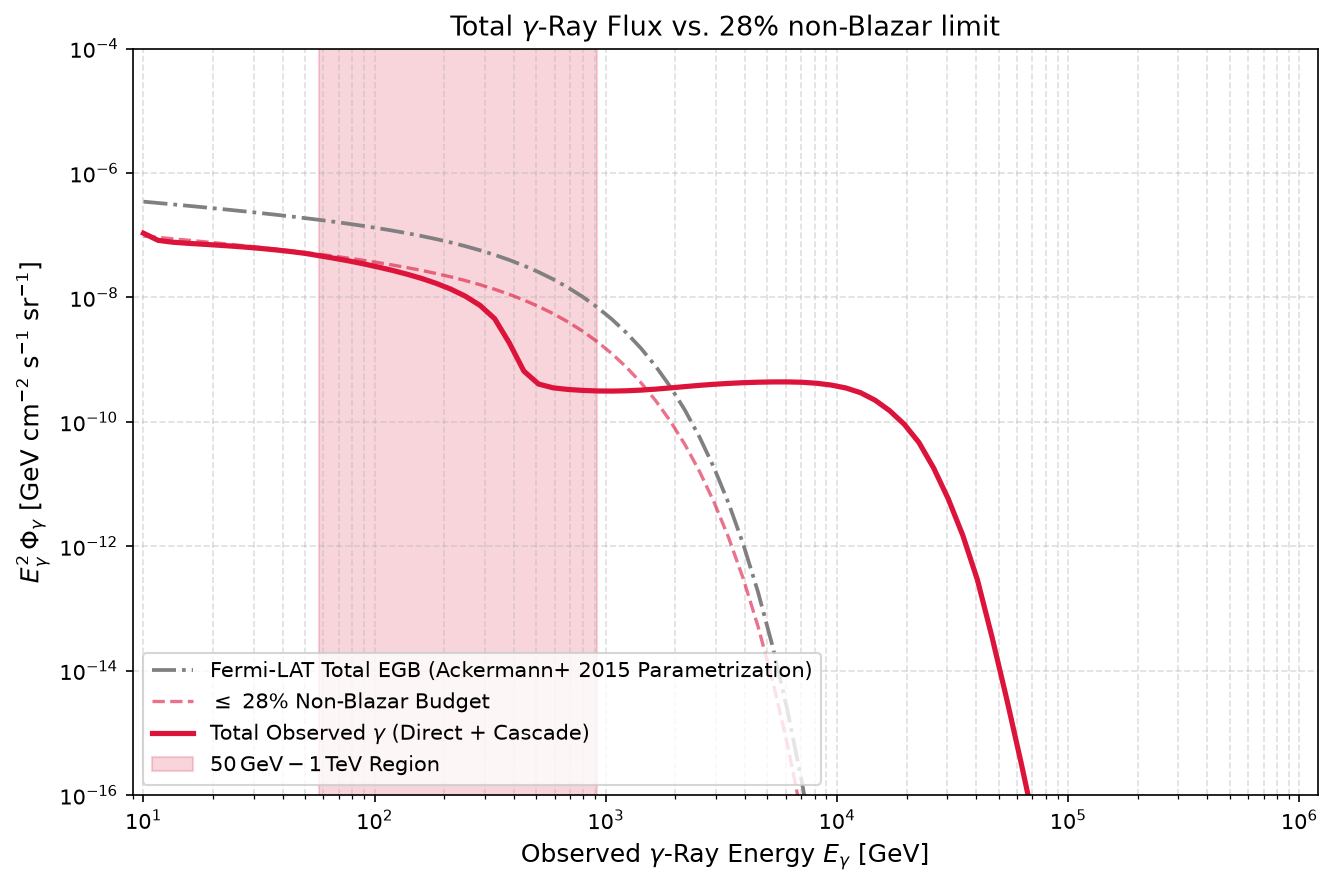

In [401]:
plt.figure(figsize=(9, 6), dpi=150)

# 1. Total Fermi EGB Extrapolation (Full Range)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_egb_flux_full,
    color="gray",
    linestyle="-.",
    lw=1.8,
    label=r"Fermi-LAT Total EGB (Ackermann+ 2015 Parametrization)",
)

# 2. 28% Non-Blazar Budget (Full Curve)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * bechtol_limit_full,
    color="crimson",
    linestyle="--",
    lw=1.6,
    alpha=0.6,
    label=r"$\leq$ 28% Non-Blazar Budget",
)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_total_observed,
    color="crimson",
    lw=2.5,
    label=r"Total Observed $\gamma$ (Direct + Cascade)",
)

plt.fill_between(
    E_bechtol_band,
    1e-20,
    1e-4,
    color="crimson",
    alpha=0.18,
    label=r"$50\,\mathrm{GeV} - 1\,\mathrm{TeV}$ Region",
)


plt.xscale("log")
plt.yscale("log")
plt.xlim(0.9e1, 1.2e6)
plt.ylim(1e-16, 1e-4)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Total $\gamma$-Ray Flux vs. 28% non-Blazar limit",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.show()

In [402]:
# -----------------------------------------------------------------------------
# 1. Integration from 0.05 TeV (10 GeV) to 1.0 TeV (1000 GeV)
# -----------------------------------------------------------------------------
E_min_int = 50.0    # 0.05 TeV in GeV
E_max_int = 1000.0  # 1.00 TeV in GeV

# Filter data within the target integration range
int_mask = (E_gamma_grid >= 50.0) & (E_gamma_grid <= 1000.0) #bechtol mask
E_int = E_gamma_grid[int_mask]

# 1. Integrated Number Flux [Nphotons cm^-2 s^-1 sr^-1]: \int \Phi(E) dE
int_num_flux_model = trapezoid(phi_total_observed[int_mask], E_int)
int_num_flux_limit = trapezoid(total_egb_flux_full[int_mask], E_int)

# 2. Integrated Energy Flux [GeV cm^-2 s^-1 sr^-1]: \int E \Phi(E) dE
int_en_flux_model = trapezoid(E_int * phi_total_observed[int_mask], E_int)
int_en_flux_limit = trapezoid(E_int * total_egb_flux_full[int_mask], E_int)

# Percentage ratio of budget consumed
pct_num = (int_num_flux_model / int_num_flux_limit) * 100.0
pct_en = (int_en_flux_model / int_en_flux_limit) * 100.0

print(f"=== Integration Range: {E_min_int/1e3:.2f} TeV to {E_max_int/1e3:.2f} TeV ({E_min_int:.0f} - {E_max_int:.0f} GeV) ===")
print(f"Total Model Gamma Number Flux : {int_num_flux_model:.4e} cm^-2 s^-1 sr^-1")
print(f"Total Fermi Number Flux : {int_num_flux_limit:.4e} cm^-2 s^-1 sr^-1")
print(f"Percentage of Fermi Number Flux : {pct_num:.2f}%\n")
print(f"Total Model Gamma Energy Flux : {int_en_flux_model:.4e} GeV cm^-2 s^-1 sr^-1")
print(f"Total Fermi Energy Flux : {int_en_flux_limit:.4e} GeV cm^-2 s^-1 sr^-1")
print(f"Percentage of Fermi Energy Flux : {pct_en:.2f}%")
print("=========================================================================")

=== Integration Range: 0.05 TeV to 1.00 TeV (50 - 1000 GeV) ===
Total Model Gamma Number Flux : 4.4478e-10 cm^-2 s^-1 sr^-1
Total Fermi Number Flux : 1.9103e-09 cm^-2 s^-1 sr^-1
Percentage of Fermi Number Flux : 23.28%

Total Model Gamma Energy Flux : 4.3838e-08 GeV cm^-2 s^-1 sr^-1
Total Fermi Energy Flux : 2.1711e-07 GeV cm^-2 s^-1 sr^-1
Percentage of Fermi Energy Flux : 20.19%


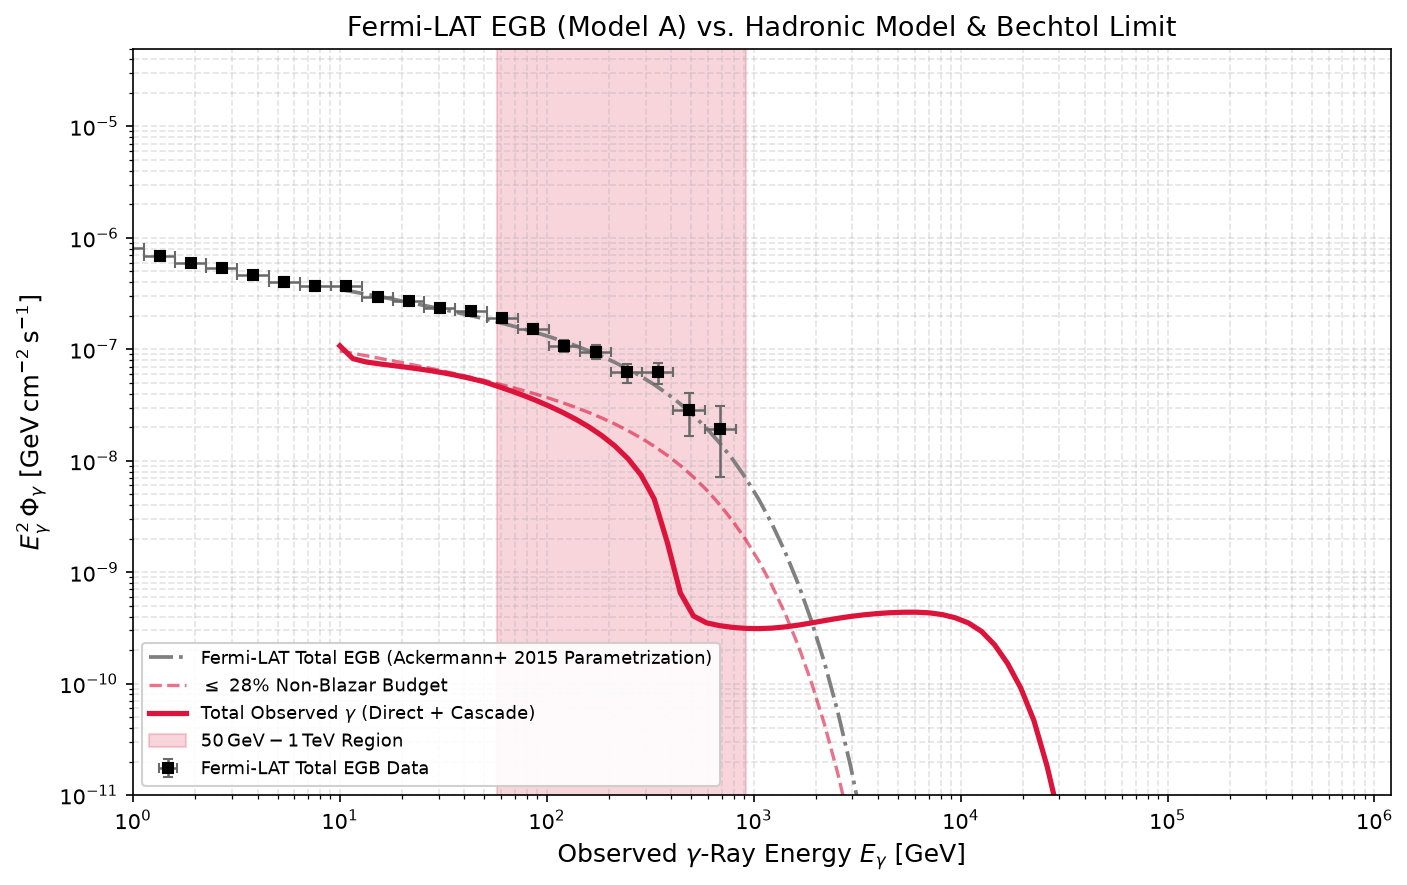

In [403]:
# -----------------------------------------------------------------------------
# 1. Direct Table from Ackermann et al. 2015 (Total EGB: Top Table)
# Columns: [E_min_MeV, E_max_MeV, Delta_F (bin flux), err_pos, err_neg]
# -----------------------------------------------------------------------------
'''
raw_egb_data = [
    [100.0, 141.4, 3.94e-06, 5.79e-07, 5.79e-07],
    [141.4, 200.0, 2.41e-06, 4.44e-07, 4.44e-07],
    [200.0, 282.8, 1.59e-06, 3.16e-07, 3.16e-07],
    [282.8, 400.0, 1.09e-06, 2.03e-07, 2.03e-07],
    [400.0, 565.7, 7.66e-07, 1.04e-07, 1.04e-07],
    [565.7, 800.0, 5.57e-07, 4.40e-08, 4.40e-08],
    [800.0, 1131.4, 3.46e-07, 2.53e-08, 2.53e-08],
    [1131.4, 1600.0, 2.15e-07, 1.58e-08, 1.58e-08],
    [1600.0, 2262.7, 1.36e-07, 1.06e-08, 1.06e-08],
    [2262.7, 3200.0, 8.87e-08, 6.26e-09, 6.26e-09],
    [3200.0, 4525.5, 5.49e-08, 4.37e-09, 4.37e-09],
    [4525.5, 6400.0, 3.45e-08, 3.19e-09, 3.19e-09],
    [6400.0, 9051.0, 2.23e-08, 2.06e-09, 2.06e-09],
    [9051.0, 12800.0, 1.52e-08, 1.35e-09, 1.35e-09],
    [12800.0, 18101.9, 8.73e-09, 7.71e-10, 7.71e-10],
    [18101.9, 25600.0, 5.53e-09, 4.77e-10, 4.77e-10],
    [25600.0, 36203.9, 3.33e-09, 2.82e-10, 2.82e-10],
    [36203.9, 51200.0, 2.16e-09, 1.82e-10, 1.82e-10],
    [51200.0, 72407.7, 1.30e-09, 1.12e-10, 1.12e-10],
    [72407.7, 102400.0, 7.27e-10, 6.84e-11, 6.81e-11],
    [102400.0, 144815.5, 3.64e-10, 4.05e-11, 4.01e-11],
    [144815.5, 204800.0, 2.20e-10, 2.78e-11, 2.74e-11],
    [204800.0, 289630.9, 1.02e-10, 1.79e-11, 1.74e-11],
    [289630.9, 409600.0, 6.86e-11, 1.37e-11, 1.32e-11],
    # --- Previously missing 2 highest-energy bins ---
    [409600.0, 579261.9, 2.45e-11, 9.10e-12, 8.70e-12],
    [579261.9, 819200.0, 1.08e-11, 6.80e-12, 6.10e-12],
]'''

raw_egb_data = [
    [100.0, 141.4, 3.67e-06, 5.73e-07, 5.73e-07],
    [141.4, 200.0, 2.32e-06, 4.42e-07, 4.42e-07],
    [200.0, 282.8, 1.47e-06, 3.14e-07, 3.14e-07],
    [282.8, 400.0, 9.70e-07, 2.02e-07, 2.02e-07],
    [400.0, 565.7, 6.73e-07, 1.03e-07, 1.03e-07],
    [565.7, 800.0, 4.87e-07, 4.24e-08, 4.24e-08],
    [800.0, 1131.4, 2.99e-07, 2.38e-08, 2.38e-08],
    [1131.4, 1600.0, 1.79e-07, 1.45e-08, 1.45e-08],
    [1600.0, 2262.7, 1.09e-07, 9.51e-09, 9.51e-09],
    [2262.7, 3200.0, 6.93e-08, 5.22e-09, 5.22e-09],
    [3200.0, 4525.5, 4.21e-08, 3.68e-09, 3.68e-09],
    [4525.5, 6400.0, 2.62e-08, 2.75e-09, 2.75e-09],
    [6400.0, 9051.0, 1.69e-08, 1.73e-09, 1.73e-09],
    [9051.0, 12800.0, 1.20e-08, 1.12e-09, 1.12e-09],
    [12800.0, 18101.9, 6.75e-09, 6.29e-10, 6.29e-10],
    [18101.9, 25600.0, 4.38e-09, 3.90e-10, 3.90e-10],
    [25600.0, 36203.9, 2.67e-09, 2.34e-10, 2.33e-10],
    [36203.9, 51200.0, 1.79e-09, 1.54e-10, 1.54e-10],
    [51200.0, 72407.7, 1.09e-09, 9.78e-11, 9.76e-11],
    [72407.7, 102400.0, 6.18e-10, 6.11e-11, 6.08e-11],
    [102400.0, 144815.5, 3.08e-10, 3.74e-11, 3.70e-11],
    [144815.5, 204800.0, 1.93e-10, 2.63e-11, 2.59e-11],
    [204800.0, 289630.9, 8.88e-11, 1.71e-11, 1.67e-11],
    [289630.9, 409600.0, 6.28e-11, 1.35e-11, 1.30e-11],
    [409600.0, 579261.9, 2.05e-11, 8.70e-12, 8.39e-12],
    [579261.9, 819200.0, 9.66e-12, 6.02e-12, 6.02e-12],
]

df = pd.DataFrame(
    raw_egb_data,
    columns=[
        "E_min_MeV",
        "E_max_MeV",
        "delta_F",
        "err_pos",
        "err_neg",
    ],
)

# Convert energies to GeV
df["E_min_GeV"] = df["E_min_MeV"] * 1e-3
df["E_max_GeV"] = df["E_max_MeV"] * 1e-3
df["delta_E_GeV"] = df["E_max_GeV"] - df["E_min_GeV"]
df["E_cen_GeV"] = np.sqrt(df["E_min_GeV"] * df["E_max_GeV"])

# Compute differential flux dN/dE = delta_F / delta_E [GeV^-1 cm^-2 s^-1] (all-sky)
df["dNdE_allsky"] = (df["delta_F"] / df["delta_E_GeV"])
df["err_allsky"] = (
 (0.5 * (df["err_pos"] + df["err_neg"]))
    / df["delta_E_GeV"]
)

# Compute E^2 * dN/dE [GeV cm^-2 s^-1]
df["E2_allsky"] = (df["E_cen_GeV"] ** 2) * df["dNdE_allsky"]
df["E2_err_allsky"] = (df["E_cen_GeV"] ** 2) * df["err_allsky"]

# -----------------------------------------------------------------------------
# 2. Fit Lines & Bechtol Ceiling (All-Sky 4*pi)
# -----------------------------------------------------------------------------
E_grid = np.logspace(-1, 4, 300)  # 0.1 GeV to 10 TeV

# Ackermann Model A Total EGB (4*pi all-sky)
# Prefactor: 1.48e-7 [cm^-2 s^-1 sr^-1] * (gamma - 1) / E_0_GeV
C_0 = 1.48e-7 * (2.31 - 1.0) / 0.1  # GeV^-1 cm^-2 s^-1 sr^-1
dNdE_fit_allsky = (
    C_0
    * (E_grid / 0.1) ** (-2.31)
    * np.exp(-E_grid / 362.0)
)
E2_fit_allsky = (E_grid**2) * dNdE_fit_allsky

# 28% Bechtol Limit
E2_bechtol_allsky = 0.28 * E2_fit_allsky
bechtol_mask = (E_grid >= 50.0) & (E_grid <= 1000.0)

# -----------------------------------------------------------------------------
# 3. Plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(9.5, 6), dpi=150)

# 1. Total EGB Data Points
plt.errorbar(
    df["E_cen_GeV"],
    df["E2_allsky"],
    xerr=[
        df["E_cen_GeV"] - df["E_min_GeV"],
        df["E_max_GeV"] - df["E_cen_GeV"],
    ],
    yerr=df["E2_err_allsky"],
    fmt="s",
    color="black",
    ecolor="dimgray",
    markersize=5,
    capsize=2.5,
    elinewidth=1.2,
    zorder=5,
    label=r"Fermi-LAT Total EGB Data",
)

# 1. Total Fermi EGB Extrapolation (Full Range)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_egb_flux_full,
    color="gray",
    linestyle="-.",
    lw=1.8,
    label=r"Fermi-LAT Total EGB (Ackermann+ 2015 Parametrization)",
)

# 2. 28% Non-Blazar Budget (Full Curve)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * bechtol_limit_full,
    color="crimson",
    linestyle="--",
    lw=1.6,
    alpha=0.6,
    label=r"$\leq$ 28% Non-Blazar Budget",
)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_total_observed,
    color="crimson",
    lw=2.5,
    label=r"Total Observed $\gamma$ (Direct + Cascade)",
)

plt.fill_between(
    E_bechtol_band,
    1e-20,
    1e-4,
    color="crimson",
    alpha=0.18,
    label=r"$50\,\mathrm{GeV} - 1\,\mathrm{TeV}$ Region",
)


# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, 1.2e6)
plt.ylim(1e-11, 5e-5)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma$ [$\mathrm{GeV}\,\mathrm{cm}^{-2}\,\mathrm{s}^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Fermi-LAT EGB (Model A) vs. Hadronic Model & Bechtol Limit",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.legend(loc="lower left", fontsize=8.8, framealpha=0.9)
plt.tight_layout()
plt.show()

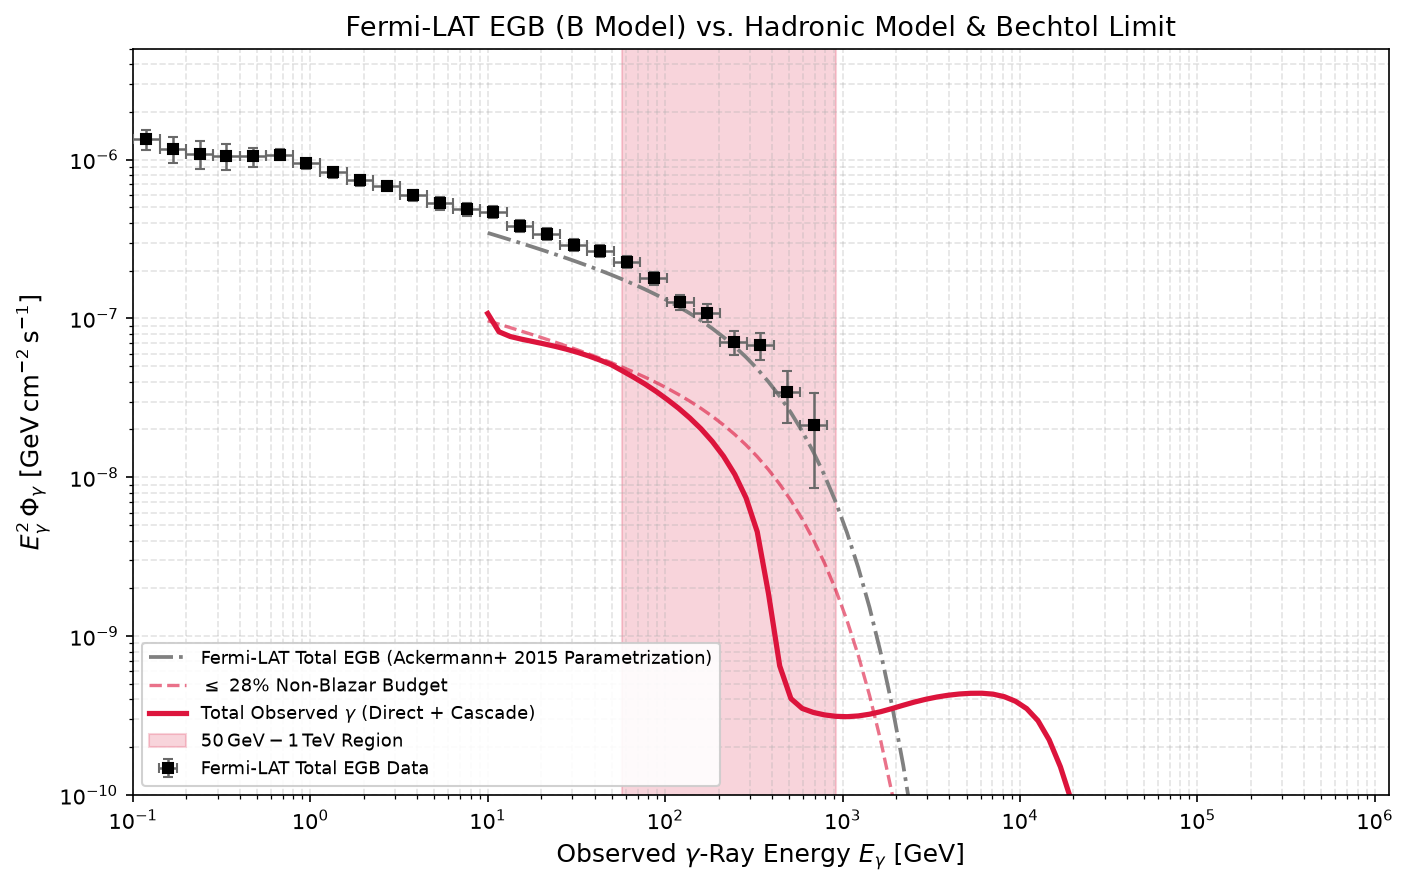

In [404]:
# -----------------------------------------------------------------------------
# 1. Direct Table from Ackermann et al. 2015 (Total EGB: Bottom Table, B Model)
# Columns: [E_min_MeV, E_max_MeV, Delta_F (bin flux), err_pos, err_neg]
# -----------------------------------------------------------------------------

raw_egb_data = [
    [100.0, 141.4, 3.94e-06, 5.79e-07, 5.79e-07],
    [141.4, 200.0, 2.41e-06, 4.44e-07, 4.44e-07],
    [200.0, 282.8, 1.59e-06, 3.16e-07, 3.16e-07],
    [282.8, 400.0, 1.09e-06, 2.03e-07, 2.03e-07],
    [400.0, 565.7, 7.66e-07, 1.04e-07, 1.04e-07],
    [565.7, 800.0, 5.57e-07, 4.40e-08, 4.40e-08],
    [800.0, 1131.4, 3.46e-07, 2.53e-08, 2.53e-08],
    [1131.4, 1600.0, 2.15e-07, 1.58e-08, 1.58e-08],
    [1600.0, 2262.7, 1.36e-07, 1.06e-08, 1.06e-08],
    [2262.7, 3200.0, 8.87e-08, 6.26e-09, 6.26e-09],
    [3200.0, 4525.5, 5.49e-08, 4.37e-09, 4.37e-09],
    [4525.5, 6400.0, 3.45e-08, 3.19e-09, 3.19e-09],
    [6400.0, 9051.0, 2.23e-08, 2.06e-09, 2.06e-09],
    [9051.0, 12800.0, 1.52e-08, 1.35e-09, 1.35e-09],
    [12800.0, 18101.9, 8.73e-09, 7.71e-10, 7.71e-10],
    [18101.9, 25600.0, 5.53e-09, 4.77e-10, 4.77e-10],
    [25600.0, 36203.9, 3.33e-09, 2.82e-10, 2.82e-10],
    [36203.9, 51200.0, 2.16e-09, 1.82e-10, 1.82e-10],
    [51200.0, 72407.7, 1.30e-09, 1.12e-10, 1.12e-10],
    [72407.7, 102400.0, 7.27e-10, 6.84e-11, 6.81e-11],
    [102400.0, 144815.5, 3.64e-10, 4.05e-11, 4.01e-11],
    [144815.5, 204800.0, 2.20e-10, 2.78e-11, 2.74e-11],
    [204800.0, 289630.9, 1.02e-10, 1.79e-11, 1.74e-11],
    [289630.9, 409600.0, 6.86e-11, 1.37e-11, 1.32e-11],
    [409600.0, 579261.9, 2.45e-11, 9.10e-12, 8.70e-12],
    [579261.9, 819200.0, 1.08e-11, 6.80e-12, 6.10e-12],
]

df = pd.DataFrame(
    raw_egb_data,
    columns=[
        "E_min_MeV",
        "E_max_MeV",
        "delta_F",
        "err_pos",
        "err_neg",
    ],
)

# Convert energies to GeV
df["E_min_GeV"] = df["E_min_MeV"] * 1e-3
df["E_max_GeV"] = df["E_max_MeV"] * 1e-3
df["delta_E_GeV"] = df["E_max_GeV"] - df["E_min_GeV"]
df["E_cen_GeV"] = np.sqrt(df["E_min_GeV"] * df["E_max_GeV"])

# Compute differential flux dN/dE = delta_F / delta_E [GeV^-1 cm^-2 s^-1] (all-sky)
df["dNdE_allsky"] = (df["delta_F"] / df["delta_E_GeV"])
df["err_allsky"] = ((0.5 * (df["err_pos"] + df["err_neg"]))
    / df["delta_E_GeV"]
)

# Compute E^2 * dN/dE [GeV cm^-2 s^-1]
df["E2_allsky"] = (df["E_cen_GeV"] ** 2) * df["dNdE_allsky"]
df["E2_err_allsky"] = (df["E_cen_GeV"] ** 2) * df["err_allsky"]

# -----------------------------------------------------------------------------
# 2. Fit Lines & Bechtol Ceiling (All-Sky 4*pi)
# -----------------------------------------------------------------------------
E_grid = np.logspace(-1, 4, 300)  # 0.1 GeV to 10 TeV

# -----------------------------------------------------------------------------
# 3. Plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(9.5, 6), dpi=150)

# 1. Total EGB Data Points
plt.errorbar(
    df["E_cen_GeV"],
    df["E2_allsky"],
    xerr=[
        df["E_cen_GeV"] - df["E_min_GeV"],
        df["E_max_GeV"] - df["E_cen_GeV"],
    ],
    yerr=df["E2_err_allsky"],
    fmt="s",
    color="black",
    ecolor="dimgray",
    markersize=5,
    capsize=2.5,
    elinewidth=1.2,
    zorder=5,
    label=r"Fermi-LAT Total EGB Data",
)

# 1. Total Fermi EGB Extrapolation (Full Range)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_egb_flux_full,
    color="gray",
    linestyle="-.",
    lw=1.8,
    label=r"Fermi-LAT Total EGB (Ackermann+ 2015 Parametrization)",
)

# 2. 28% Non-Blazar Budget (Full Curve)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * bechtol_limit_full,
    color="crimson",
    linestyle="--",
    lw=1.6,
    alpha=0.6,
    label=r"$\leq$ 28% Non-Blazar Budget",
)

plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * phi_total_observed,
    color="crimson",
    lw=2.5,
    label=r"Total Observed $\gamma$ (Direct + Cascade)",
)

plt.fill_between(
    E_bechtol_band,
    1e-20,
    1e-4,
    color="crimson",
    alpha=0.18,
    label=r"$50\,\mathrm{GeV} - 1\,\mathrm{TeV}$ Region",
)


# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.1, 1.2e6)
plt.ylim(1e-10, 5e-6)
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma$ [$\mathrm{GeV}\,\mathrm{cm}^{-2}\,\mathrm{s}^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Fermi-LAT EGB (B Model) vs. Hadronic Model & Bechtol Limit",
    fontsize=13,
)
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.legend(loc="lower left", fontsize=8.8, framealpha=0.9)
plt.tight_layout()
plt.show()

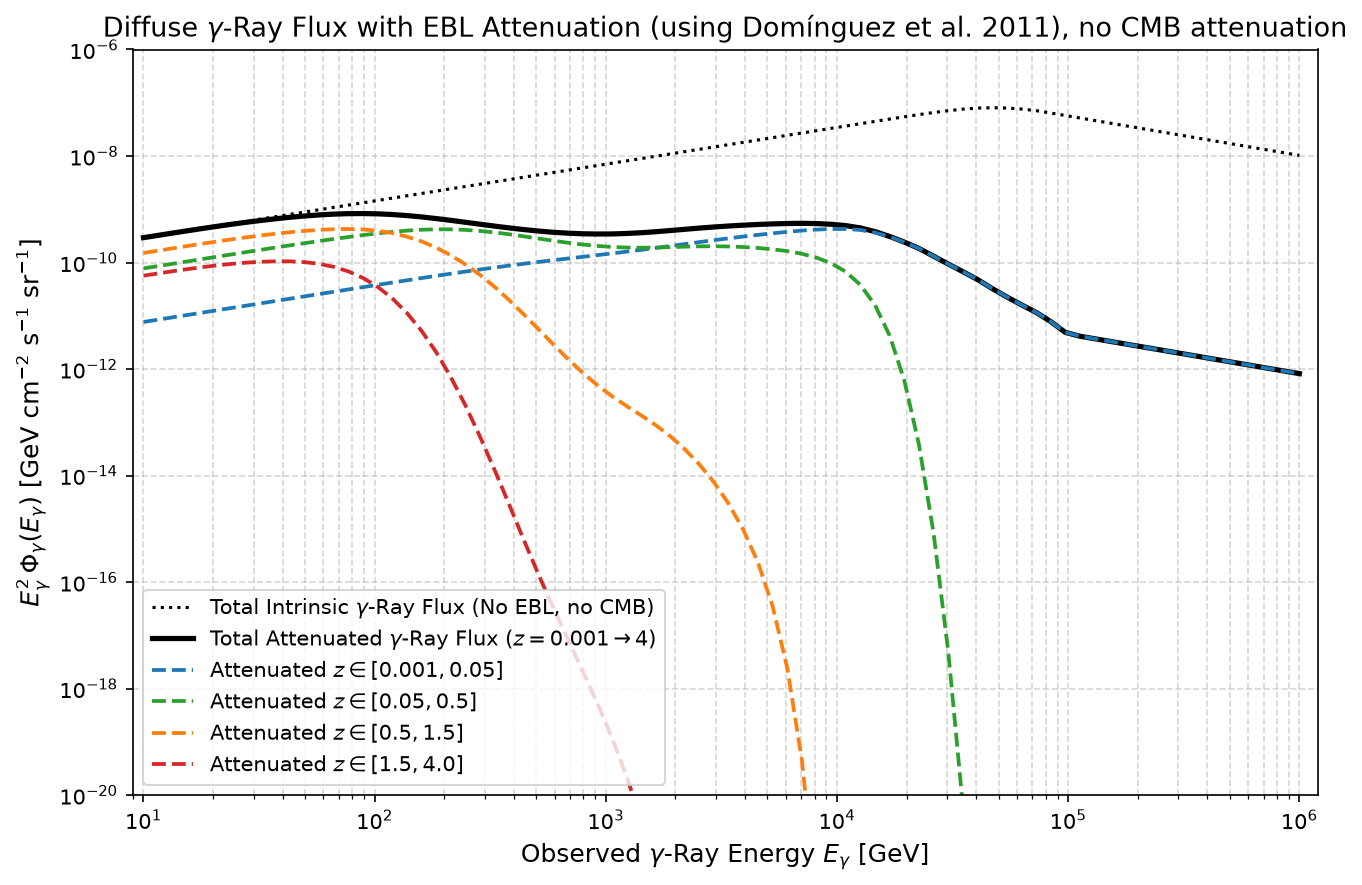

In [405]:
# Energy grid: 10 GeV (10^1 GeV) to 1 PeV (10^6 GeV)
E_gamma_grid = np.logspace(1, 6, 80)
z_slices = [
    (0.001, 0.05),  # Resolves VHE / PeV local CMB horizon
    (0.05, 0.5),  # Resolves 1-10 TeV EBL cutoff
    (0.5, 1.5),  # Resolves peak cosmic star formation
    (1.5, 4.0),  # Deep universe, optically thin for Fermi-LAT band
]

# Total attenuated gamma-ray flux
total_gamma_ebl = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=True, apply_cmb=False
)

# Total unattenuated (intrinsic) gamma-ray flux for reference
total_gamma_intrinsic = integrate_gamma_flux(
    E_gamma_grid, z_min=0.001, z_max=4.0, apply_ebl=False, apply_cmb=False
)

plt.figure(figsize=(9, 6), dpi=150)

# Plot intrinsic vs attenuated total
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_intrinsic,
    "k:",
    lw=1.5,
    label=r"Total Intrinsic $\gamma$-Ray Flux (No EBL, no CMB)",
)
plt.plot(
    E_gamma_grid,
    E_gamma_grid**2 * total_gamma_ebl,
    "k-",
    lw=2.5,
    label=r"Total Attenuated $\gamma$-Ray Flux ($z = 0.001 \to 4$)",
)

# Plot redshift bin contributions with EBL and CMB attenuation
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
for idx, (z_lo, z_hi) in enumerate(z_slices):
    partial_gamma_ebl = integrate_gamma_flux(
        E_gamma_grid, z_min=z_lo, z_max=z_hi, apply_ebl=True, apply_cmb=False,
    )
    plt.plot(
        E_gamma_grid,
        E_gamma_grid**2 * partial_gamma_ebl,
        linestyle="--",
        lw=1.8,
        color=colors[idx],
        label=rf"Attenuated $z \in [{z_lo}, {z_hi}]$",
    )

# Formatting
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Observed $\gamma$-Ray Energy $E_\gamma$ [GeV]", fontsize=12)
plt.ylabel(
    r"$E_\gamma^2 \, \Phi_\gamma(E_\gamma)$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]",
    fontsize=12,
)
plt.title(
    r"Diffuse $\gamma$-Ray Flux with EBL Attenuation (using Domínguez et al. 2011), no CMB attenuation",
    fontsize=13,
)
plt.ylim(1e-20, 1e-6)
plt.xlim(0.9e1, 1.2e6)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()